In [1]:
import numpy as np
import pandas as pd
import glob, os, warnings, shutil, subprocess, re, sys
from Bio import Seq, SeqIO
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import scipy
from matplotlib.ticker import ScalarFormatter
import lifelines
from datetime import datetime

sys.path.append("scripts")
from variant_analysis_utils import *
# from epi_utils import *

h37Rv_path = "./H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))

h37Rv_regions = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_v4.csv"))

# these are promoters, transcriptional signals, or RNAs. Exclude these
non_coding_regions = h37Rv_regions.query("Feature != 'CDS'").Name.values

# if these remain in the dataframe, then there will be multiple entires for a single gene name, which will cause process_intergenic_variant_WHO_catalog_coord to fail
h37Rv_regions = h37Rv_regions.query("~Feature.str.contains('|'.join(['promoter', 'signal']), case=False)")
assert len(h37Rv_regions) == h37Rv_regions.Name.nunique()

h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv.gz"), compression='gzip')
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

# isolates with matched LR sequencing (including samples from the same patient where only 1 sample had LR done)
isolates_with_LR = pd.read_csv("./data/TRUST_isolates_long_read_aln.tsv", sep='\t', header=None)

TRUST_data_dir = "/home/sak0914/TRUST_data_processing/processed_data"
CNN_results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

silent_lst = ['initiator_codon_variant', 'synonymous_variant', 'stop_retained_variant']

out_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"
F2_thresh = 0.03

VCF_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

df_WGS = pd.read_csv(f"{TRUST_data_dir}/20250818_combined_patient_WGS_data.csv")
df_WGS.SampleID.nunique()

880248 runs of at least 2
730854 nucleotides are in homopolymeric tracts


In [2]:
from epi_utils import *

# Variants Present in ≥N% of Isolates

https://pmc.ncbi.nlm.nih.gov/articles/PMC11459938/

This paper did in vitro selection using artemisinin, an antimaliarial. They found mutations in glpK (multiple frameshifts in the homopolymeric tract) and glpQ1 (1 frameshift = 4315194	ATC>AC)

# Get Genome-Wide Phase Variants and Matrices for Samples 1 and 2 for each pid

In [3]:
df_pids = pd.read_csv("./data/pids_WGS_data.csv")

# fix lineages. Sometimes the names got converted to integers for the single number lineages
for i, row in df_pids.iterrows():
    if not pd.isnull(row['Lineage']):
        if type(row['Lineage']) != str:
            df_pids.loc[i, 'Lineage'] = str(int(row['Lineage']))

df_pids['Lineage'] = df_pids['Lineage'].astype(str)
df_pids['Lineage'] = df_pids['Lineage'].replace('nan', np.nan)

print(f"{df_pids.pid.nunique()} pids")
df_pids['Lineage'].value_counts()

# .query("Low_Qual != 1")
df_variants = pd.concat([pd.read_csv("./results/genome/fixed_variants.csv"), 
                         pd.read_csv("./results/genome/unfixed_variants.csv")]).reset_index(drop=True)

406 pids


In [34]:
# sample_1_variants, sample_2_variants = get_matrix_of_variants_ROI(df_variants,
#                                                                   df_longitudinal_pids,
#                                                                   sample_2=True,
#                                                                   binarize_fixed_variants=False,
#                                                                   fixed_thresh=0.95,
#                                                                   absent_thresh=0.05
#                                                                  )

# # subtract to get a difference matrix
# variant_differences = sample_2_variants - sample_1_variants

# sample_1_variants.to_csv("./results/genome/sample_1_variants.csv.gz", compression='gzip')
# sample_2_variants.to_csv("./results/genome/sample_2_variants.csv.gz", compression='gzip')
# variant_differences.to_csv("./results/genome/variant_differences.csv.gz", compression='gzip')

271 samples with 12276 variants


In [4]:
# prpR = Rv1129c
regions_of_interest = ['Rv1129c', 'glpK', 'eccB3', 
                     'espR', 'espA', 'espK',
                     'bioF2', 'ponA1', 
                     'vapC2', 'Rv0302', # intergenic region between these two
                     'Rv0678',
                     'Rv0759c', 'Rv0760c', # intergenic region between these two
                     'PPE13',
                     'Rv1373',
                     'PE_PGRS25', # low empirical base pair recall
                     'lysX', 'infC', # intergenic region between these two
                     'wag22', # low empirical base pair recall
                     'Rv1894c',
                     'Rv2177c', 'aroG', # intergenic region between these two
                     'Rv2264c',
                     'lipR',
                     'PPE53', # low empirical base pair recall
                     'Rv3192',
                     'Rv3413c',
                     'B11', # small regulatory RNA
                    ]

# check for variants in the intergenic regions by checking for variants with downstream_genes in the name. The downstream genes are downstream of the variant,
# which means that variant is upstream of the gene
upstream_genes = ['vapC2', 'Rv0759c', 'lysX', 'Rv2177c', 'Rv3848']
downstream_genes = ['Rv0302', 'Rv0760c', 'infC', 'aroG', 'espR']

df_variants_ROI = pd.concat([df_variants.query("variant.str.contains('|'.join(@regions_of_interest))"),
                             df_variants.query("variant.str.contains('|'.join(@downstream_genes)) & variant.str.contains('_c.-')")
                            ]).drop_duplicates().reset_index(drop=True)

In [5]:
df_longitudinal_pids = pd.read_csv(f"./data/longitudinal_pids_WGS_data.csv")
print(f"{df_longitudinal_pids.pid.nunique()} pids")

pids_with_low_F2 = pd.DataFrame(df_longitudinal_pids.query("F2 <= @F2_thresh").groupby('pid')['SampleID'].nunique()).query("SampleID > 1").index.values

print(f"{len(pids_with_low_F2)}/{df_longitudinal_pids.pid.nunique()} pids have F2 ≤ {F2_thresh} for both samples")

# additionally require pids to have had the EXACT same lineage
pids_with_same_lineage = pd.DataFrame(df_longitudinal_pids.query("pid in @pids_with_low_F2").groupby('pid')['Coll2014'].nunique()).query("Coll2014 == 1").index.values
pids_with_same_lineage = pd.DataFrame(df_longitudinal_pids.query("pid in @pids_with_same_lineage").groupby('pid')['Freschi2020'].nunique()).query("Freschi2020 == 1").index.values

print(f"{len(pids_with_same_lineage)}/{len(pids_with_low_F2)} pids have the same Coll2014 lineages")

df_longitudinal_pids = df_longitudinal_pids.query("pid in @pids_with_same_lineage").reset_index(drop=True)

299 pids
279/299 pids have F2 ≤ 0.03 for both samples
271/279 pids have the same Coll2014 lineages


In [6]:
# sample_1_variants, sample_2_variants = get_matrix_of_variants_ROI(df_variants_ROI,
#                                                                   df_longitudinal_pids,
#                                                                   sample_2=True,
#                                                                   binarize_fixed_variants=False,
#                                                                   fixed_thresh=0.95,
#                                                                   absent_thresh=0.05
#                                                                  )

# # subtract to get a difference matrix
# variant_differences = sample_2_variants - sample_1_variants

271 samples with 181 variants


In [ ]:
# get a list of variants to plot. Only plot variants with a change in at least freq_thresh pids
freq_thresh = 5
variants_with_change_thresh = []

for col in variant_differences.columns:
    if len(variant_differences.loc[variant_differences[col].abs() >= 0.1]) >= freq_thresh:
        variants_with_change_thresh.append(col)
        
print(f"{len(variants_with_change_thresh)}/{sample_1_variants.shape[1]} variants have a change")

Text(0.5, 1.0, 'Change in Allele Fraction between First and Second WGS Samples in Non-Coding Homopolymeric Tracts in 271 pids')

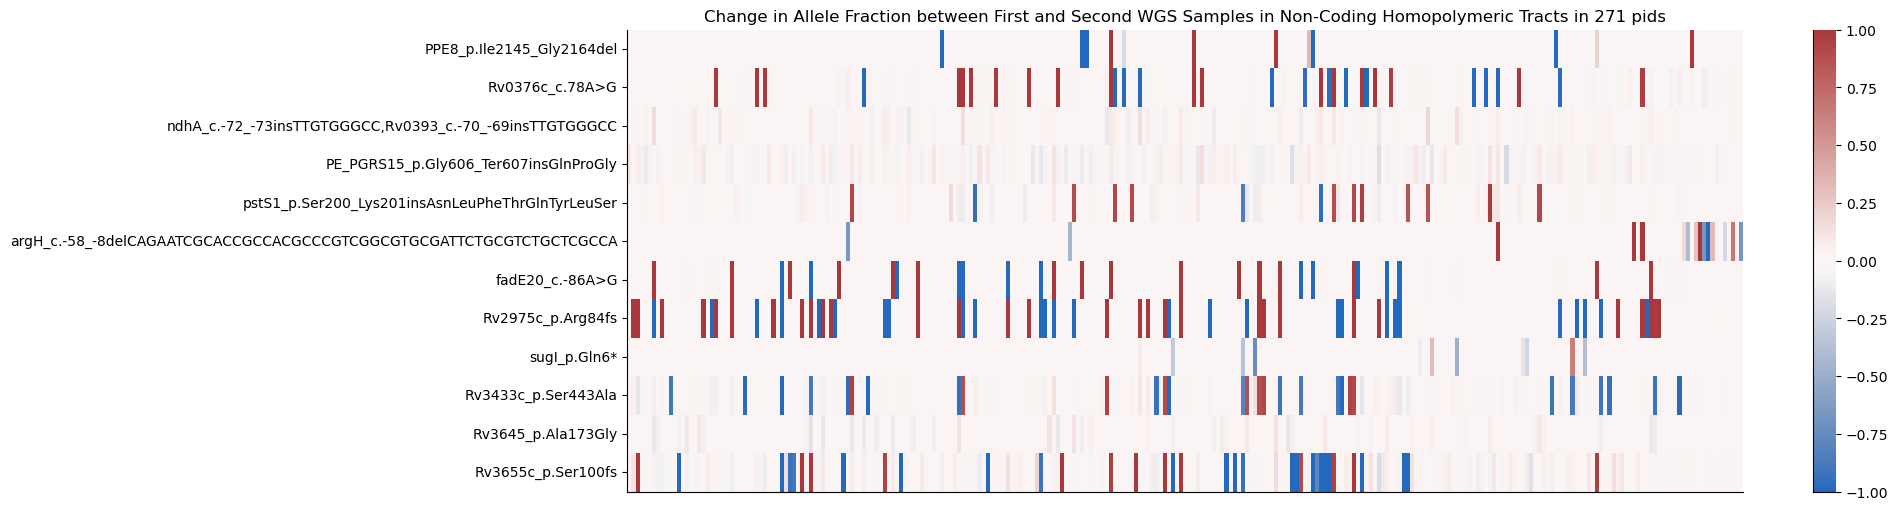

In [41]:
fig, ax = plt.subplots(figsize=(18, 6))

sns.heatmap(variant_differences[variants_with_change_thresh].T,
            center=0,
            cmap=sns.color_palette("vlag", as_cmap=True),
            ax=ax,
            xticklabels=False,
           )

sns.despine()
plt.title(f"Change in Allele Fraction between First and Second WGS Samples in Non-Coding Homopolymeric Tracts in {variant_differences.shape[0]} pids")
# plt.savefig("./results/figures/longitudinal_changes_noncoding_regions.svg", bbox_inches='tight')

In [9]:
pids_with_changes = pd.DataFrame(np.sum(np.abs(variant_differences), axis=1))
pids_with_changes.columns = ['Num_Changes']
pids_with_changes.sort_values('Num_Changes', ascending=False)

,Num_Changes
T0245,1.022127
T0222,0.841104
T0090,0.740890
T0475,0.385358
T0362,0.376656
...,...
T0356,0.000000
T0133,0.000000
T0437,0.000000
T0320,0.000000


In [151]:
var = 'espA_c.-805G>T,ephA_c.-553C>A'

variant_differences.loc[variant_differences[var] != 0][var]

T0099   -0.286822
Name: espA_c.-805G>T,ephA_c.-553C>A, dtype: float64

In [152]:
df_longitudinal_pids.query("pid=='T0099'")

,pid,Original_ID,SampleID,Sampling_Week,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,Paired_Sample_Num,total_samples
124,T0099,S0099-01,MFS-738,1,2.2.1,2.2.1.1.1,"beijing,mungi",lin2.2.1,NaN,0.009158,2,1,3
125,T0099,S0099-08,MFS-872,8,2.2.1,2.2.1.1.1,"beijing,mungi",lin2.2.1,NaN,0.008483,2,2,3


In [153]:
df_WGS.query("pid=='T0099'").sort_values('Original_ID').dropna(subset='Lineage')

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,Perc_Reads_Mapped,...,duration_of_use_meth,duration_of_use_mandrax,lca,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Sampling_Week
2,T0099,S0099-01,MFS-738,MFS-738_lib72901,NaN,NaN,1.0,298.11,0.99,0.9883,...,1.0,24.0,1.0,0.638285,NaN,0.011482,2.2.1,2.2.1.1.1,2.0,1
1,T0099,S0099-06,MFS-871,MFS-871_lib83826,NaN,NaN,1.0,420.73,0.99,0.9848,...,1.0,24.0,1.0,0.638285,NaN,0.010294,2.2.1,2.2.1.1.1,2.0,6
0,T0099,S0099-08,MFS-872,MFS-872_lib83827,NaN,NaN,1.0,437.00,0.99,0.9851,...,1.0,24.0,1.0,0.638285,NaN,0.010216,2.2.1,2.2.1.1.1,2.0,8


In [154]:
var = 'espK_p.Ser361_Ala379del'

variant_differences.loc[variant_differences[var] != 0][var]

T0020    0.090909
T0082   -1.000000
T0178    1.000000
T0244    1.000000
T0328   -1.000000
Name: espK_p.Ser361_Ala379del, dtype: float64

In [155]:
sample_1_variants.loc['T0020', var], sample_2_variants.loc['T0020', var]

(0.9090909090909092, 1.0)

In [156]:
df_longitudinal_pids.query("pid in ['T0082', 'T0178', 'T0244', 'T0328']")

,pid,Original_ID,SampleID,Sampling_Week,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,Paired_Sample_Num,total_samples
110,T0082,82-01,MFS-47,1,3.1.1,3.1.1.i1,"east_african_indian,ghana,mungi",NaN,NaN,0.009832,3,1,2
111,T0082,82-08,MFS-48,8,3.1.1,3.1.1.i1,"east_african_indian,ghana,mungi",NaN,NaN,0.010253,3,2,2
218,T0178,S0178-01,MFS-269,1,3.1.1,3.1.1.i1,"east_african_indian,ghana,mungi",NaN,NaN,0.011611,3,1,2
219,T0178,S0178-05,MFS-622,5,3.1.1,3.1.1.i1,"east_african_indian,ghana,mungi",NaN,NaN,0.008874,3,2,2
296,T0244,244-01,MFS-154,1,3.1.1,3.1.1.i1,"east_african_indian,ghana,mungi",NaN,NaN,0.010024,3,1,2
297,T0244,244-04,MFS-155,4,3.1.1,3.1.1.i1,"east_african_indian,ghana,mungi",NaN,NaN,0.011144,3,2,2
382,T0328,S0328-01,MFS-391,1,3.1.1,3.1.1.i1,"east_african_indian,ghana,mungi",NaN,NaN,0.009794,3,1,2
383,T0328,S0328-08,MFS-392,8,3.1.1,3.1.1.i1,"east_african_indian,ghana,mungi",NaN,NaN,0.009155,3,2,2


In [131]:
df_WGS.groupby('pid')['SampleID'].nunique().sort_values()

pid
T0001    1
T0326    1
T0327    1
T0333    1
T0161    1
        ..
T0157    4
T0149    4
T0272    5
T0402    5
T0099    5
Name: SampleID, Length: 424, dtype: int64

In [160]:
df_variants.query("variant==@var & pid=='T0082'")

,SampleID,pid,Sampling_Week,Paired_Sample_Num,POS,REF,ALT,QUAL,DP,DPB,...,F2,Lineage,Coll2014,HT,variant,Diff_NT,Unique_Change_NT,Phase_Variant,SNP,Low_Qual
172000,MFS-47,T0082,1,1,4358645,GCGCGGCGGCCGCCGCCCGTGCGCCCGGGACACCGGACGCCGCAGC...,G,288.836,10,0.338983,...,0.009832,3,3.1.1,0,espK_p.Ser361_Ala379del,CGCGGCGGCCGCCGCCCGTGCGCCCGGGACACCGGACGCCGCAGCC...,4.0,0,0,NaN


In [128]:
df_WGS.query("pid in ['T0082', 'T0178', 'T0244', 'T0328']")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,Perc_Reads_Mapped,...,duration_of_use_meth,duration_of_use_mandrax,lca,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Sampling_Week
385,T0178,S0178-05,MFS-622,MFS-622_lib66015,NaN,NaN,1.0,366.75,1.0,0.9706,...,NaN,NaN,3.0,0.965114,NaN,0.011209,3.1.1,3.1.1.i1,3,5
386,T0178,S0178-01,MFS-269,MFS-269_lib51739,NaN,NaN,1.0,242.83,1.0,0.9899,...,NaN,NaN,3.0,0.965114,NaN,0.014301,3.1.1,3.1.1.i1,3,1
555,T0328,S0328-08,MFS-392,MFS-392_lib59207,NaN,NaN,1.0,249.44,1.0,0.9899,...,NaN,NaN,2.0,0.324914,1.0,0.012999,3.1.1,3.1.1.i1,3,8
556,T0328,S0328-01,MFS-391,MFS-391_lib59206,NaN,NaN,1.0,193.08,1.0,0.9891,...,NaN,NaN,2.0,0.324914,1.0,0.011270,3.1.1,3.1.1.i1,3,1
640,T0244,244-01,MFS-154,MFS-154_lib47333,NaN,NaN,1.0,275.48,1.0,0.9870,...,NaN,NaN,3.0,0.506930,NaN,0.012705,3.1.1,3.1.1.i1,3,1
641,T0244,244-04,MFS-155,MFS-155_lib47334,NaN,NaN,1.0,562.69,1.0,0.9832,...,NaN,NaN,3.0,0.506930,NaN,0.013178,3.1.1,3.1.1.i1,3,4
689,T0082,82-01,MFS-47,MFS-47_lib47034,NaN,NaN,1.0,318.41,1.0,0.9877,...,NaN,NaN,3.0,0.274302,NaN,0.012186,3.1.1,3.1.1.i1,3,1
690,T0082,82-08,MFS-48,MFS-48_lib47035,NaN,NaN,1.0,337.46,1.0,0.9878,...,NaN,NaN,3.0,0.274302,NaN,0.011875,3.1.1,3.1.1.i1,3,8


In [121]:
len('GCGCGGCGGCCGCCGCCCGTGCGCCCGGGACACCGGACGCCGCAGCCGGCGTCACCGA')

58

In [124]:
df_variants.query("variant.str.contains('espK_p.Ser361')").sort_values(['pid', 'SampleID'])

,SampleID,pid,Sampling_Week,Paired_Sample_Num,POS,REF,ALT,QUAL,DP,DPB,...,F2,Lineage,Coll2014,HT,variant,Diff_NT,Unique_Change_NT,Phase_Variant,SNP,Low_Qual
818622,MFS-523,T0020,1,1,4358645,GCGCGGCGGCCGCCGCCCGTGCGCCCGGGACACCGGACGCCGCAGC...,G,263.417,11,1.338980,...,0.011338,3,3.1.1,0,espK_p.Ser361_Ala379del,CGCGGCGGCCGCCGCCCGTGCGCCCGGGACACCGGACGCCGCAGCC...,4.0,0,0,0.0
574996,MFS-718,T0020,5,2,4358645,GCGCGGCGGCCGCCGCCCGTGCGCCCGGGACACCGGACGCCGCAGC...,G,776.266,23,0.779661,...,0.010014,3,3.1.1,0,espK_p.Ser361_Ala379del,CGCGGCGGCCGCCGCCCGTGCGCCCGGGACACCGGACGCCGCAGCC...,4.0,0,0,NaN
627631,MFS-20,T0039,1,1,4358645,GCGCGGCGGCCGCCGCCCGTGCGCCCGGGACACCGGACGCCGCAGC...,G,556.775,19,0.661017,...,0.010501,3,3.1.1,0,espK_p.Ser361_Ala379del,CGCGGCGGCCGCCGCCCGTGCGCCCGGGACACCGGACGCCGCAGCC...,4.0,0,0,NaN
776829,MFS-21,T0039,6,2,4358645,GCGCGGCGGCCGCCGCCCGTGCGCCCGGGACACCGGACGCCGCAGC...,G,370.177,13,0.457627,...,0.010480,3,3.1.1,0,espK_p.Ser361_Ala379del,CGCGGCGGCCGCCGCCCGTGCGCCCGGGACACCGGACGCCGCAGCC...,4.0,0,0,NaN
230201,MFS-553,T0068,1,1,4358645,GCGCGGCGGCCGCCGCCCGTGCGCCCGGGACACCGGACGCCGCAGC...,G,332.852,12,0.711864,...,0.011617,3,3.1.1,0,espK_p.Ser361_Ala379del,CGCGGCGGCCGCCGCCCGTGCGCCCGGGACACCGGACGCCGCAGCC...,4.0,0,0,NaN
611181,MFS-554,T0068,7,2,4358645,GCGCGGCGGCCGCCGCCCGTGCGCCCGGGACACCGGACGCCGCAGC...,G,487.177,17,0.576271,...,0.009723,3,3.1.1,0,espK_p.Ser361_Ala379del,CGCGGCGGCCGCCGCCCGTGCGCCCGGGACACCGGACGCCGCAGCC...,4.0,0,0,NaN
26958,MFS-557,T0073,1,1,4358645,GCGCGGCGGCCGCCGCCCGTGCGCCCGGGACACCGGACGCCGCAGC...,G,434.778,15,0.508475,...,0.009635,3,3.1.1,0,espK_p.Ser361_Ala379del,CGCGGCGGCCGCCGCCCGTGCGCCCGGGACACCGGACGCCGCAGCC...,4.0,0,0,NaN
331794,MFS-560,T0080,1,1,4358645,GCGCGGCGGCCGCCGCCCGTGCGCCCGGGACACCGGACGCCGCAGC...,G,431.434,15,0.508475,...,0.003007,4,4.3.4.2.1,0,espK_p.Ser361_Ala379del,CGCGGCGGCCGCCGCCCGTGCGCCCGGGACACCGGACGCCGCAGCC...,4.0,0,0,NaN
172000,MFS-47,T0082,1,1,4358645,GCGCGGCGGCCGCCGCCCGTGCGCCCGGGACACCGGACGCCGCAGC...,G,288.836,10,0.338983,...,0.009832,3,3.1.1,0,espK_p.Ser361_Ala379del,CGCGGCGGCCGCCGCCCGTGCGCCCGGGACACCGGACGCCGCAGCC...,4.0,0,0,NaN
621712,MFS-737,T0096,1,1,4358645,GCGCGGCGGCCGCCGCCCGTGCGCCCGGGACACCGGACGCCGCAGC...,G,525.102,16,0.542373,...,0.008200,3,3.1.1,0,espK_p.Ser361_Ala379del,CGCGGCGGCCGCCGCCCGTGCGCCCGGGACACCGGACGCCGCAGCC...,4.0,0,0,NaN


In [ ]:
df_variants.query("variant.str.contains('espA')")

# Cox Models

In [12]:
# freebayes_VCFs = []
# freebayes_samples = []

# for sample in df_WGS.dropna(subset='Lineage').SampleID.values:
    
#     fName = f"/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/{sample}/freebayes/{sample}.SNPs.vcf"
    
#     assert os.path.isfile(fName)
    
#     freebayes_VCFs.append(fName)
#     freebayes_samples.append(sample)
    
# print(len(freebayes_VCFs))

# pd.Series(freebayes_VCFs).to_csv("./data/freebayes_VCF_fNames.txt", sep='\t', header=None, index=False)

## TCC

In [69]:
def add_indel_at_baseline_to_patient_data(df, sample_1_variants, variant, freq_thresh=3):
    
    num_samples_variant_initial = sample_1_variants[variant].sum()

    if num_samples_variant_initial < freq_thresh:
        print(f"    Fewer than {freq_thresh} patients have {variant} at at baseline. Skipping this variant...")
        return None
    
    # add an AF variable for whether the variable is present at baseline
    df_with_variant = df.merge(sample_1_variants[[variant]], left_on='pid', right_index=True).rename(columns={variant: 'Indel_Sample1'})

    return df_with_variant

# Build a patient data model using all relevant patient predictors

## First determine the model form by checking the proportional hazards assumption

In [104]:
cols_lst = [
            'screen_sex',
            'screen_years',
            'underweight',
            'peth_value_baseline',
            'fstrom1_baseline', # smoking yes or no
            'smoked_substance_use',
            'HIV_CD4',
            'bl_prevtb',
            'TTP_baseline',
            'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
            'diabetes',
            'high_lung_involvement',
            'F2',
            'Lineage' # Lineage_3 is so rare and causes instabilities / needs to be stratified by
           ]

MIC_type = 'none'

# try these first, as they were required for the full TCC model
stratify_covariates = ['smear_pos_no_contam_sputum_specimen_1', 'HIV_CD4', 'high_lung_involvement', 'underweight']

non_linear_term_variables = []

df_trust_patients = pd.read_csv(f"{TRUST_data_dir}/20250827_cleaned_patient_outcomes_data.csv").dropna(subset='Lineage')

df_imputed_TCC = pd.read_csv(f"{TRUST_data_dir}/imputed_TCC.csv").query("pid in @df_trust_patients.pid")

# use the lineage information from TRUST_lowAF, whereas 20250825_cleaned_patient_outcomes_data contains data from Illumina_culture_WGS_processed 
df_pids_for_outcomes_model = df_trust_patients.sort_values("Sampling_Week").drop_duplicates(subset='pid', keep='first')

del_cols = ['F2', 'Lineage', 'Coll2014', 'Freschi2020']

for col in del_cols:
    if col in df_pids_for_outcomes_model.columns:
        del df_pids_for_outcomes_model[col]
        
df_pids_for_outcomes_model = df_pids_for_outcomes_model.merge(df_pids, on=['pid', 'Original_ID', 'SampleID', 'Sampling_Week'])
        
df_pids_for_outcomes_model, TRUST_phenos, df_pred_combined = read_combine_all_TRUST_data(df_pids_for_outcomes_model, 
                                                                                         {'RIF': 'lineage_amino_acid',
                                                                                          'INH': 'lineage_amino_acid',
                                                                                          'EMB': 'lineage_amino_acid',
                                                                                          'PZA': 'amino_acid'}, 
                                                                                         CNN_results_dir,
                                                                                         F2_thresh=1, 
                                                                                         baseline_only=True
                                                                                        )

df_pids_for_outcomes_model['inh_resistant'] = (df_pids_for_outcomes_model['pid'].isin(TRUST_phenos.query("INH_lower_bound >= 0.1").pid.values)).astype(int)

df_pids_for_outcomes_model['underweight'] = (df_pids_for_outcomes_model['bl_bmi'] < 18).astype(int)

len(df_pids_for_outcomes_model), df_pids_for_outcomes_model.pid.nunique()

406 patients with uncontaminated WGS samples
400 patients with uncontaminated WGS samples taken in the first 2 weeks

0 patients: [] have multiple sequences at the same timepoint
Removing 0 patients: [] because there are multiple WGS samples at the same timepoint with different lineages
398 patients have MICs for RIF
398 patients have MICs for INH
398 patients have MICs for EMB
280 patients have MICs for PZA
398 patients have measured MICs in the first 2 weeks

Found predicted RIF MICs for 400 pids
Found predicted INH MICs for 400 pids
Found predicted EMB MICs for 400 pids
Found predicted PZA MICs for 400 pids
400 patients have predicted MICs


(400, 400)

In [105]:
df_pids_for_outcomes_model.underweight.value_counts()

underweight
1    219
0    181
Name: count, dtype: int64

In [106]:
df_test_results, df_samples_imputations, cph_models_imputations = fit_cox_models_all_imputations(df_pids_for_outcomes_model,
                                                                                                  df_pred_combined, 
                                                                                                 TRUST_phenos,
                                                                                                  df_imputed_TCC,
                                                                                                  cols_lst,
                                                                                                  event_col = 'culture_convert',
                                                                                                  time_col = 'TCC',
                                                                                                 MIC_type = 'measured',
                                                                                                 include_drugs = [],
                                                                                                  invert_OR=True,
                                                                                                  stratify_variables=stratify_covariates,
                                                                                                 binary_lineage=True
                                                                                                 )

df_violating_covariates = []

for model_idx in range(len(cph_models_imputations)):

    df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_models_imputations[model_idx], df_samples_imputations[model_idx], time_transform='rank').summary

    # diabetes has a p-value of like 0.0105
    violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
    
    violating_covariates['imp_num'] = model_idx + 1

    df_violating_covariates.append(violating_covariates)

df_violating_covariates = pd.concat(df_violating_covariates)

    349 total pids


In [109]:
df_violating_covariates.query("p <= 0.01").covariate.value_counts()#.drop_duplicates('covariate')

Series([], Name: count, dtype: int64)

In [110]:
df_test_results.query("pval <= 0.05")[['covariate', 'pval', 'HR_TCC_assoc', 'HR_TCC_assoc_lower', 'HR_TCC_assoc_upper']]

,covariate,pval,HR_TCC_assoc,HR_TCC_assoc_lower,HR_TCC_assoc_upper
2,TTP_baseline,0.000018,0.256447,0.139390,0.471809
8,screen_years,0.001613,1.023505,1.008969,1.038251


## Check that the association between TCC and the stratified variables make sense

Smear Positivity: χ^2 = 34.90350374874218, p = 3.4645684553895127e-09


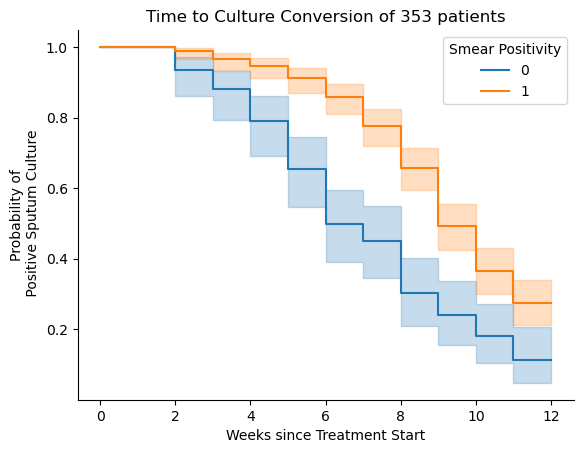

HIV, CD4 Count: χ^2 = 11.28692045886994, p = 0.003540595911452471


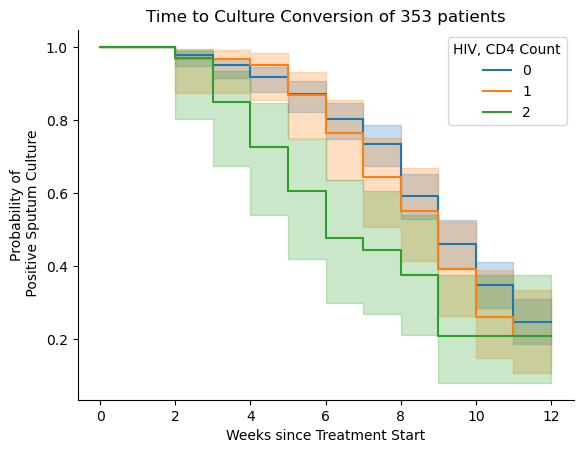

> 20% Lung Affected: χ^2 = 22.40626348088546, p = 2.206532477822477e-06


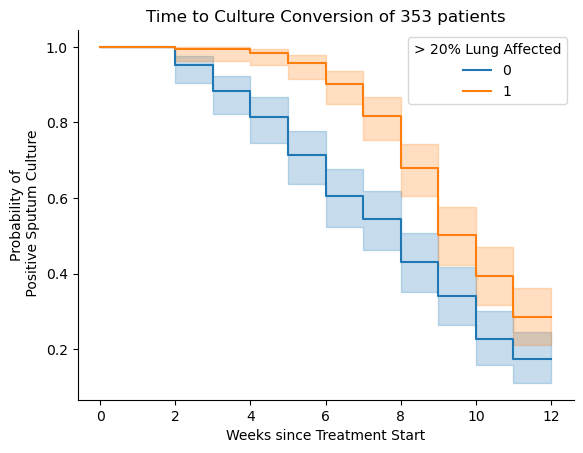

BMI < 18: χ^2 = 4.870231549874272, p = 0.027323833942379788


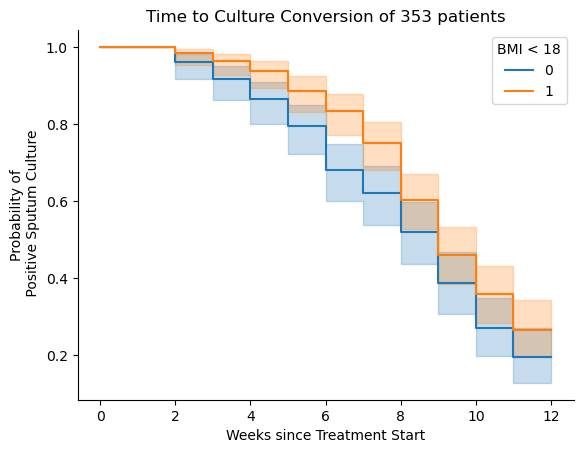

In [113]:
imp_num = 0
df_check_stratify_vars = df_pids_for_outcomes_model.merge(df_imputed_TCC.query("imp_num==@imp_num")[['pid', 'TCC', 'culture_convert']], on='pid')
df_check_stratify_vars['high_lung_involvement'] = (df_check_stratify_vars['predicted_PLI'] > 20)
df_check_stratify_vars = df_check_stratify_vars.dropna(subset=stratify_covariates)
df_check_stratify_vars['high_lung_involvement'] = df_check_stratify_vars['high_lung_involvement'].astype(int)
df_check_stratify_vars['underweight'] = (df_check_stratify_vars['bl_bmi'] < 18).astype(int)

labels_dict = {'smear_pos_no_contam_sputum_specimen_1': 'Smear Positivity', 
               'high_lung_involvement': '> 20% Lung Affected', 
               'cxr_cavity_chest_radiograph_1': 'Cavitation',
               'HIV_CD4': 'HIV, CD4 Count',
               'screen_sex': 'Sex',
               'underweight': 'BMI < 18'
              }

color_dict = dict(zip([0, 1, 2], sns.color_palette().as_hex()))

HIV_CD4_dict = {0: 'HIV–', 1: 'HIV+, CD4 ≥ 200', 2: 'HIV+, CD4 < 200'}

for variable in stratify_covariates:

    fig, ax = plt.subplots()

    df_check_stratify_vars[variable] = df_check_stratify_vars[variable].astype(int)

    # sort so that 0 is plotted before 1
    for group in np.sort(df_check_stratify_vars[variable].unique()):
    
        df_single_group = df_check_stratify_vars.query(f"{variable}==@group")
        kmf = lifelines.KaplanMeierFitter()
        kmf.fit(df_single_group['TCC'], event_observed=df_single_group['culture_convert'], label=group)
        kmf.plot_survival_function(ax=ax, show_censors=False, color=color_dict[group], censor_styles={"marker": "+", "ms": 8, "mew": 0.5})#, label=f"{labels_dict[group]} = {len(df_single_group)}")

        plt.legend(title=labels_dict[variable])

    logRank_test_results = lifelines.statistics.multivariate_logrank_test(event_durations=df_check_stratify_vars['TCC'], 
                                                                          groups=df_check_stratify_vars[variable], 
                                                                          event_observed=df_check_stratify_vars['culture_convert'], 
                                                                         )

    print(f"{labels_dict[variable]}: χ^2 = {logRank_test_results.test_statistic}, p = {logRank_test_results.p_value}")

    plt.title(f"Time to Culture Conversion of {df_check_stratify_vars.pid.nunique()} patients")
    plt.ylabel("Probability of\n Positive Sputum Culture") #
    plt.xlabel("Weeks since Treatment Start")
    sns.despine()
    plt.show()
    # plt.savefig(f"./results/figures/TCC/KM_estimate_TCC_stratified_{labels_dict[variable].replace(' ', '_').replace(',', '').replace('>', '')}.svg", bbox_inches='tight')

# Run models with all variants

In [ ]:
df_results_all_indels = []

# test only variants that have are fixed (AF > 0.95) in at least one sample at baseline. Don't include variants thare never fixed at baseline.
test_variants_lst = pd.DataFrame(sample_1_variants.max(axis=0)).reset_index().rename(columns={'index': 'variant', 0:'AF_max'}).query("AF_max > 0.95")['variant'].values

print(f"Testing associations between TCC and {len(test_variants_lst)} phase variants")

for variant in test_variants_lst:
    
    # only test variants that are present in at least 2 lineages because otherwise it's probably a lineage effect
    if df_variants.query("variant==@variant").Coll2014.nunique() > 1:

        print(f"Testing {variant}")

        df_imputed_patient_data_single_variant = add_indel_at_baseline_to_patient_data(df_pids_for_outcomes_model, 
                                                                                         sample_1_variants,
                                                                                         variant,
                                                                                         freq_thresh=5,
                                                                                         )

        # will be None if there are not enough patients with the specified change in the indel
        if df_imputed_patient_data_single_variant is not None:

    #         pids_with_change = variant_differences_grouped_pathways.loc[(variant_differences_grouped_pathways[variant] >= 0.1) | (variant_differences_grouped_pathways[variant] <= -0.1)].index.values

    #         # only include the Indel_Change variable if is at least 1 patient in each even / no event group with an AF change. Otherwise, you get perfect separation
    #         # of the groups, and the hazard ratio estimates will be huge and unreliable
    #         if df_imputed_TCC.loc[df_imputed_TCC['imp_num']==0].query("pid in @pids_with_change")['culture_convert'].nunique() == 2:
    #             predictors_lst = final_patient_predictors + ['inh_resistant', 'Lineage'] + ['Indel_Sample1', 'Indel_Change']
    #         else:
    #             predictors_lst = final_patient_predictors + ['inh_resistant', 'Lineage'] + ['Indel_Sample1']

            df_test_results_indel, _, _ = fit_cox_models_all_imputations(df_imputed_patient_data_single_variant,
                                                                          df_pred_combined, 
                                                                            TRUST_phenos,
                                                                          df_imputed_TCC,
                                                                         cols_lst + ['Indel_Sample1'],
                                                                          event_col = 'culture_convert',
                                                                          time_col = 'TCC',
                                                                          invert_OR=True,
                                                                         MIC_type = MIC_type,
                                                                        include_drugs = ['INH'],
                                                                          stratify_variables=stratify_covariates,
                                                                         binary_lineage=True
                                                                         )


            df_test_results_indel['Indel'] = variant

            df_results_all_indels.append(df_test_results_indel)
    
df_results_all_indels = pd.concat(df_results_all_indels)

fName = "./results/TCC/tolerance_genes_variants.csv"

df_results_all_indels.to_csv(fName, index=False)
df_results_all_indels = pd.read_csv(fName)

Testing associations between TCC and 203 phase variants
Testing espK_p.Val269fs
    349 total pids
Testing espK_c.588C>T
    349 total pids
Testing ponA1_p.Gln365His
    349 total pids
Testing Rv1373_p.Gln177Pro
    349 total pids
Testing ponA1_c.-241G>A
    349 total pids
Testing espA_p.Ala128Val
    349 total pids
Testing espK_c.-46C>T
    349 total pids
Testing bioF2_c.-251T>C
    349 total pids
Testing ponA1_p.Ile41Met
    349 total pids
Testing espK_p.Pro593Ser
    349 total pids
Testing Rv0302_c.-107_-106insG
    Fewer than 5 patients have Rv0302_c.-107_-106insG at at baseline. Skipping this variant...
Testing wag22_p.Phe553Leu
    349 total pids
Testing lysX_c.2985G>A
    349 total pids
Testing espA_c.-318C>A,ephA_c.-1040G>T
    349 total pids
Testing espA_c.-771G>A,ephA_c.-587C>T
    349 total pids
Testing bioF2_p.Ile268Thr
    349 total pids


In [102]:
MIC_type

'none'

In [142]:
# fName = "./results/TCC/indel_baseline.csv"
# df_results_all_indels = pd.read_csv(fName)

In [143]:
df_results_all_indels.query("pval <= 0.05").drop_duplicates(subset='covariate')[['covariate', 'Indel', pval', 'HR_TCC_assoc_lower', 'HR_TCC_assoc_upper']]

,covariate,coef_pooled,V_w,V_b,V_t,se_pooled,riv,wald_stat,dof_old,lambda,dof_observed,dof_adj,pval,t_critical,coef_lower,coef_upper,HR_TCC_assoc,HR_TCC_assoc_lower,HR_TCC_assoc_upper,Indel
3,Indel_Sample1,0.759040,0.099089,0.023911,0.123797,0.351848,0.249355,2.157298,728.001732,0.199587,308.971604,216.911906,0.032082,1.970961,0.065562,1.452518,0.468115,0.233980,0.936541,espR_c.-145_-144insG
5,TTP_baseline,1.300591,0.061954,0.023226,0.085954,0.293180,0.387391,4.436158,371.959959,0.279223,278.231053,159.169858,0.000017,1.974980,0.721567,1.879614,0.272371,0.152649,0.485990,espR_c.-145_-144insG
11,screen_years,-0.025206,0.000037,0.000016,0.000053,0.007303,0.434373,-3.451483,316.225722,0.302831,269.117913,145.388113,0.000730,1.976415,-0.039640,-0.010772,1.025526,1.010831,1.040436,espR_c.-145_-144insG


In [64]:
def read_in_adjust_confidence_intervals(fName, OR_col='OR', alpha=0.05):
    
    df = pd.read_csv(fName)
    
    # transform some hazard ratios for interpretability
    # 1. Age: make it for each decade
    # 2. RIF AUC: by 10. It ranges from 0 - 120, but mostly 0-70. Nah, the confidence interval looks weird.
    # 3: % lung involvement: by 10 also. Ranges from 0-80. Nah, makes it huge. Stick to 1%

    # compute confidence intervals. CI = coef_pooled ± t_stat * se_pooled
    # df_pool['t_critical'] = np.abs(st.t.ppf(1 - alpha / 2, df_pool['dof_adj']))
    df['t_critical'] = np.abs(st.t.ppf(1 - alpha / 2, df['dof_old']))
    df['coef_lower'] = df['coef_pooled'] - df['t_critical'] * df['se_pooled']
    df['coef_upper'] = df['coef_pooled'] + df['t_critical'] * df['se_pooled']

    # finally for interpretation, invert the hazard ratio (which is the exponentiated coefficient) so that >1 means associated with longer TCC (more hazardous, longer time to cure)
    if 'HR' in OR_col:
        df[OR_col] = 1 / np.exp(df['coef_pooled'])
        df[f'{OR_col}_lower'] = 1 / np.exp(df['coef_upper'])
        df[f'{OR_col}_upper'] = 1 / np.exp(df['coef_lower'])

    for col in ['screen_years']:#, 'RIF_AUC']:
        df.loc[df['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df.loc[df['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10
        
    return df

In [220]:
df_TCC_results = read_in_adjust_confidence_intervals("./results/TCC/pathway_grouped_gene_frameshifts_lowF2.csv", OR_col='HR_TCC_assoc', alpha=0.05)

In [221]:
df_TCC_results.query("pval <= 0.05").covariate.unique()

array(['RIF_AUC', 'screen_years'], dtype=object)

In [222]:
df_TCC_results.query("pval <= 0.05 & covariate.str.contains('|'.join(['Sample', 'Indel']))").Indel.unique()

array([], dtype=object)

In [77]:
def plot_survival_curve_by_indel(df_patient_data, df_outcome, event_variable, duration_variable, variant, sample_1_variants, sample_2_variants, variant_differences, exclude_fixed_absent=False, change_thresh=0.05, fixed_thresh=0.75, freq_thresh=5, logrank_test_compare_groups=['Gain', 'Loss'], colors_dict = {'Gain': '#1f77b4', 'Loss': '#ff7f0e', 'Fixed': '#d62728', 'Absent': '#2ca02c'}, p=0, q=0, save=False):

    if 'imp_num' not in df_outcome.columns:
        df_outcome['imp_num'] = 0
                
    # df_imputed_patient_data_single_variant = add_change_to_indel_to_patient_data(df_patient_data, 
    #                                                                              sample_1_variants, 
    #                                                                              sample_2_variants, 
    #                                                                              variant_differences,
    #                                                                              variant, 
    #                                                                              freq_thresh=freq_thresh
    #                                                                             )
    
    df_imputed_patient_data_single_variant = add_indel_at_baseline_to_patient_data(df_patient_data, 
                                                                                 sample_1_variants, 
                                                                                 variant, 
                                                                                )

    if df_imputed_patient_data_single_variant is not None:

        # for variable in stratify_covariates:
        df_plot_outcome = df_outcome.query("imp_num==0").merge(df_imputed_patient_data_single_variant[['pid', 'Indel_Sample1']])

        df_plot_outcome.loc[(df_plot_outcome['Indel_Sample1'] <= change_thresh), 'Group'] = 'Absent'
        df_plot_outcome.loc[(df_plot_outcome['Indel_Sample1'] > change_thresh) & (df_plot_outcome['Indel_Sample1'] <= fixed_thresh), 'Group'] = 'Unfixed'
        df_plot_outcome.loc[(df_plot_outcome['Indel_Sample1'] > fixed_thresh), 'Group'] = 'Fixed'
        
        # df_plot_outcome.loc[(df_plot_outcome['Indel_Sample1'] <= change_thresh) & (df_plot_outcome['Indel_Change'] <= change_thresh), 'Group'] = 'Absent'
        
        # df_plot_outcome.loc[(df_plot_outcome['Indel_Sample1'] >= 0) & (df_plot_outcome['Indel_Change'] < -change_thresh), 'Group'] = 'Loss'
        # df_plot_outcome.loc[(df_plot_outcome['Indel_Sample1'] >= 0) & (df_plot_outcome['Indel_Change'] > change_thresh), 'Group'] = 'Gain'
        
        # df_plot_outcome.loc[(df_plot_outcome['Indel_Sample1'] >= 0.75) & (df_plot_outcome['Indel_Change'] <= change_thresh) & (df_plot_outcome['Indel_Change'] >= -change_thresh), 'Group'] = 'Fixed'
        
        df_plot_outcome['Group'] = df_plot_outcome['Group'].replace('nan', np.nan)
        
        # if len(df_plot_outcome.query("Group in ['Gain', 'Loss']")) < freq_thresh:
        #     print(f"Fewer than {freq_thresh} pids have a change in {variant} of at least {change_thresh}")
        #     return None

        if sum(pd.isnull(df_plot_outcome['Group'])) > 0:
            print(df_plot_outcome.loc[pd.isnull(df_plot_outcome['Group'])])
            raise ValueError()

        fig, ax = plt.subplots()
                
        # sort so that 0 is plotted before 1
        for group in np.sort(df_plot_outcome['Group'].unique()):
            
            if not exclude_fixed_absent:
                df_single_group = df_plot_outcome.query("Group==@group")
                kmf = lifelines.KaplanMeierFitter()
                kmf.fit(df_single_group[duration_variable], event_observed=df_single_group[event_variable], label=group)
                kmf.plot_survival_function(ax=ax, color=colors_dict[group], show_censors=True, censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, label=f"{group} = {len(df_single_group)}")
            else:
                if group not in ['Fixed', 'Absent']:
                    df_single_group = df_plot_outcome.query("Group==@group")
                    kmf = lifelines.KaplanMeierFitter()
                    kmf.fit(df_single_group[duration_variable], event_observed=df_single_group[event_variable], label=group)
                    kmf.plot_survival_function(ax=ax, color=colors_dict[group], show_censors=True, censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, label=f"{group} = {len(df_single_group)}")            

        # weight = [S(t)]^p * [1 - S(t)]^q, where S(t) is the survival function. 
        # p = 1 and q = 1 weights the middle the most
        # p = 0 and q = 0 doesn't weight by the survival function
        logRank_test_full = lifelines.statistics.multivariate_logrank_test(event_durations=df_plot_outcome[duration_variable],
                                                                      groups=df_plot_outcome['Group'],
                                                                      event_observed=df_plot_outcome[event_variable],
                                                                      weightings='fleming-harrington',
                                                                      p = p, # p = 1 weights early times more
                                                                      q = q, # q = 1 weights late times more
                                                                     )
        
        assert len(logrank_test_compare_groups) == 2
        group_1, group_2 = logrank_test_compare_groups
        assert group_1 != group_2
        
        # p = 0 and q = 0 doesn't weight by the survival function
        logRank_test_2_groups = lifelines.statistics.multivariate_logrank_test(event_durations=df_plot_outcome.query("Group in @logrank_test_compare_groups")[duration_variable],
                                                                              groups=df_plot_outcome.query("Group in @logrank_test_compare_groups")['Group'],
                                                                              event_observed=df_plot_outcome.query("Group in @logrank_test_compare_groups")[event_variable],
                                                                              weightings='fleming-harrington',
                                                                              p = p, # p = 1 weights early times more
                                                                              q = q, # q = 1 weights late times more
                                                                             )

        print(f"{variant}: χ^2 = {logRank_test_full.test_statistic}, p = {logRank_test_full.p_value}")

        plt.xlabel("Weeks since Treatment Start")
        sns.despine()
        plt.legend(title='Indel Change')        
        
        if duration_variable == 'TCC':
            plt.title(f"Time to Culture Conversion of {df_plot_outcome.pid.nunique()} patients\nstratified by changes in {variant}\np ({group_1} vs. {group_2}) = {np.round(logRank_test_2_groups.p_value, 2)}")
            plt.ylabel("Probability of\n Positive Sputum Culture") #
            
            if save:
                plt.savefig(f"./results/figures/TCC/{variant}_KM_curve.svg", bbox_inches='tight')
            else:
                plt.show()
                
        else:
            plt.ylabel("Probability of No Event")
            plt.title(f"Time to Unfavorable Outcomes of {df_plot_outcome.pid.nunique()} patients\nstratified by changes in {variant}\np ({group_1} vs. {group_2}) = {np.round(logRank_test_2_groups.p_value, 2)}")
            
            if save:
                plt.savefig(f"./results/figures/outcomes/{variant}_KM_curve.svg", bbox_inches='tight')
            else:
                plt.show()

        return df_plot_outcome

espR_c.-145_-144insG: χ^2 = 1.2062217450882222, p = 0.2720816885962507


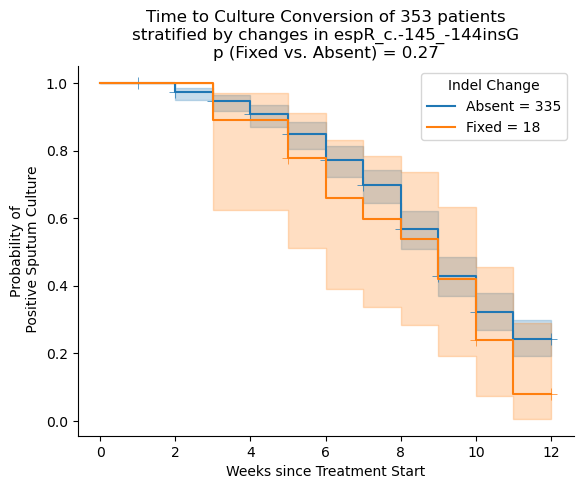

In [151]:
# for i, row in df_TCC_results.query("pval <= 1 & covariate.str.contains('Indel')")[['covariate', 'Indel']].iterrows():
for indel in ['espR_c.-145_-144insG']:
        
    df_plot_TCC = plot_survival_curve_by_indel(df_pids_for_outcomes_model,
                                                   df_imputed_TCC,
                                                   'culture_convert',
                                                   'TCC',
                                                   indel, 
                                                   sample_1_variants, 
                                                   sample_1_variants, 
                                                   sample_1_variants, 
                                                   exclude_fixed_absent=False,
                                                   change_thresh=0.05, 
                                               fixed_thresh=0.05,
                                                   freq_thresh=5,
                                                   logrank_test_compare_groups=['Fixed', 'Absent'], 
                                                   colors_dict = {'Fixed': '#ff7f0e', 'Absent': '#1f77b4', 'Gain': '#2ca02c', 'Loss': '#d62728', 'Unfixed': 'black'},
                                                   p=0,
                                                   q=0
                                                  )
    
    print("\n")

In [147]:
var = 'espR_c.-145_-144insG'

sample_1_variants.loc[sample_1_variants[var] != 0][var]

T0310    0.975806
T0298    1.000000
T0385    1.000000
T0441    0.793003
T0446    0.978723
T0475    0.636364
T0071    0.990881
T0127    0.996933
T0136    0.990566
T0152    0.818182
T0090    0.289286
T0342    0.981818
T0053    1.000000
T0089    0.990338
T0052    0.991189
T0230    0.987500
T0041    1.000000
T0176    0.986667
T0263    0.978166
Name: espR_c.-145_-144insG, dtype: float64

In [218]:
# AF_change_thresh_plot = 0

# plot_AF_matrix = plot_AF_matrix.loc[(plot_AF_matrix[variant] > AF_change_thresh_plot) | (plot_AF_matrix[variant] < -AF_change_thresh_plot)]

# fig, ax = plt.subplots(figsize=(9, 4))

# # Loop through samples and draw arrows
# for i, row in plot_AF_matrix.iloc[::-1, :].iterrows():
#     ax.annotate(
#         '', xy=(row['Sample2'], row['pid']), xytext=(row['Sample1'], row['pid']),
#         arrowprops=dict(arrowstyle='->,head_length=0.5,head_width=0.3', color='steelblue', lw=2)
#     )
#     # add point markers for the AFs
#     ax.plot(row['Sample1'], row['pid'], 'o', color='gray', zorder=0, markersize=8, label='Sample 1')
#     ax.plot(row['Sample2'], row['pid'], 'o', color='black', zorder=0, markersize=8, label='Sample 2')

# # plt.axvline(0.05, color='darkred', linestyle='--', linewidth=0.8, label = '(0.05, 0.9]')
# # plt.axvline(0.90, color='darkred', linestyle='--', linewidth=0.8, label = '(0.05, 0.9]')
# ax.set_xlabel('Allele Frequency (AF)')
# ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
# ax.set_title(f'Longitudinal Changes in {variant}')
# # plt.grid(axis='x', linestyle='--', alpha=0.5)
# handles, labels = ax.get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# ax.legend(by_label.values(), by_label.keys(), fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5))
# sns.despine()
# plt.tight_layout()
# # plt.show()
# plt.savefig(f"./results/figures/{variant}_within_sample_changes.svg")

# Do pids with espR Indel have higher Isoniazid MIC at baseline?

According to this paper they did: https://pmc.ncbi.nlm.nih.gov/articles/PMC11898584

In [114]:
# get all pids with the variant ever
variant = 'espR_c.-145_-144insG'

pids_with_variant_of_interest = sample_1_variants.loc[(sample_1_variants[variant] > 0.95)].index.values

TRUST_phenos['inh_resistant'] = (TRUST_phenos['INH_lower_bound'] >= 0.1).astype(int)

TRUST_phenos['espR_indel'] = TRUST_phenos['pid'].isin(pids_with_variant_of_interest).astype(int)

TRUST_phenos.pid.nunique()

398

In [115]:
TRUST_phenos.espR_indel.value_counts()

espR_indel
0    383
1     15
Name: count, dtype: int64

In [116]:
st.mannwhitneyu(TRUST_phenos.query("espR_indel==0")['INH_midpoint'],
                TRUST_phenos.query("espR_indel==1")['INH_midpoint'],
                alternative='less'
               )

MannwhitneyuResult(statistic=2151.0, pvalue=0.02429183658811595)

In [118]:
TRUST_phenos.groupby('espR_indel')[['inh_resistant', 'INH_midpoint']].mean()

,inh_resistant,INH_midpoint
espR_indel,,
0,0.062663,0.048727
1,0.133333,0.067083


<Axes: xlabel='INH_lower_bound', ylabel='Probability'>

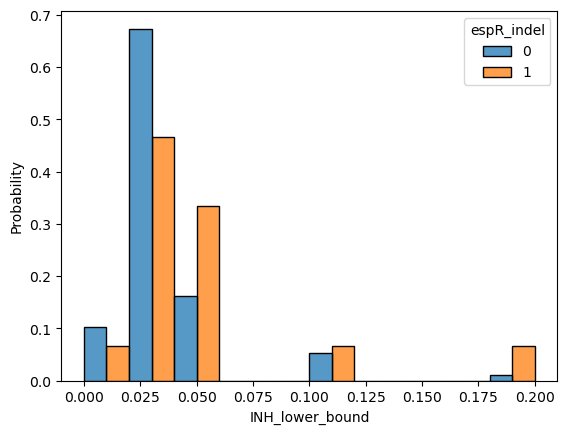

In [126]:
sns.histplot(data=TRUST_phenos,
             x='INH_lower_bound',
             hue='espR_indel',
             multiple='dodge',
             stat='probability',
             common_norm=False
            )

# Composite Poor Outcomes

In [60]:
# to_studyto_treatment_outcome column. 
# Other descriptions in to_studyto_other_treatment_outcome
# additional comments in to_comments_treatment_outcome
treatment_outcome_dict = {1: 'cure',
                          2: 'complete',
                          3: 'defaulted', # typically they stopped taking treatment entirely, not just interruption. May have been doctor-recommended, like due to liver injury or something
                          4: 'failure',
                          5: 'extension',
                          6: 'death',
                          7: 'transferred',
                          8: 'lost_fu',
                          9: 'other'
                        }

# esp_reason_end_of_study_parti column
# Other descriptions in esp_reasonoth_end_of_study_parti
esp_dict = {1: 'complete', # completed all study requirements
            2: 'inappropriate', # should not have been included in the study
            3: 'withdrew',
            4: 'failure', # includes both groups 4 and 5 in treatment_outcome_dict, meaning the patient was culture positive at month 5 or tx was extended
            5: 'relapse',
            6: 'moved', # moved/transferred out,
            7: 'lost_fu',
            8: 'death',
            9: 'other'
            }

cols_lst = [
            'screen_sex',
            'screen_years',
            'underweight',
            'peth_value_baseline',
            'fstrom1_baseline', # smoking yes or no
            'smoked_substance_use',
            'HIV_CD4',
            'bl_prevtb',
            'TTP_baseline',
            'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
            'diabetes',
            'high_lung_involvement',
            'F2',
            'Lineage' # Lineage_3 is so rare and causes instabilities / needs to be stratified by
           ]


tb_deaths_only = False #True

MIC_type = 'predicted'

# try these first, as they were required for the full TCC model
stratify_covariates = []

In [61]:
df_tx_outcomes = pd.read_csv(f"{TRUST_data_dir}/tx_outcomes.csv")

print(f"Maximum event date: {df_tx_outcomes.weeks.max()} weeks")

Maximum event date: 99.57142857142856 weeks


In [62]:
df_tx_outcomes.event.value_counts()

event
0    364
1     42
Name: count, dtype: int64

In [63]:
# 6 of these deaths were censored, so 35 - 6 = 29 above
df_tx_outcomes.event_type.value_counts()

event_type
cure          355
relapse        23
death          16
tx_failure     12
Name: count, dtype: int64

In [64]:
df_test_results, df_samples_imputations, cph_models_imputations = fit_cox_models_all_imputations(df_pids_for_outcomes_model,
                                                                                                  df_pred_combined, 
                                                                                                 TRUST_phenos,
                                                                                                  df_tx_outcomes,
                                                                                                  cols_lst,
                                                                                                  event_col = 'event',
                                                                                                  time_col = 'date',
                                                                                                  exclude_resistance=False,
                                                                                                  MIC_type=MIC_type,
                                                                                                 include_drugs=['RIF'],
                                                                                                 binarize_drugs=['RIF'],
                                                                                                  tb_deaths_only=tb_deaths_only,
                                                                                                  invert_OR=False,
                                                                                                  stratify_variables=stratify_covariates,
                                                                                                 binary_lineage=True
                                                                                                 )

df_violating_covariates = []

for model_idx in range(len(cph_models_imputations)):

    df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_models_imputations[model_idx], df_samples_imputations[model_idx], time_transform='rank').summary

    # diabetes has a p-value of like 0.0105
    violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
    
    violating_covariates['imp_num'] = model_idx + 1

    df_violating_covariates.append(violating_covariates)

df_violating_covariates = pd.concat(df_violating_covariates)
df_violating_covariates.query("p <= 0.05")

Binarized RIF_pred_MIC at 0.05999994 µg/mL, 37.2% are high
    377 total pids


,covariate,p,imp_num
10,peth_value_baseline,0.029788,1


In [65]:
# df_samples_imputations[0].query("RIF_pred_MIC_high > 0").merge(df_trust_patients[['pid', 'Lineage']].drop_duplicates()).Lineage.value_counts()

In [66]:
df_test_results.query("pval <= 0.05")

,covariate,coef,exp(coef),se(coef),coef_transformed,se_transformed,imp_num,pval,OR,OR_lower,OR_upper
5,HIV_Low_CD4,0.310436,1.364019,0.140174,1.042067,0.470536,1,0.026785,2.835072,1.127310,7.129923
11,RIF_pred_MIC_high,0.602450,1.826589,0.279338,1.245224,0.577374,1,0.031029,3.473714,1.120295,10.770990


In [28]:
# close_variants_lst = []

# for i, row in df_variants.drop_duplicates(subset=['POS', 'variant']).reset_index(drop=True).iterrows():
    
#     variant = row['variant']
    
#     if variant not in close_variants_lst:
        
#         # get all variants within 10 nts
#         close_variant_idx = np.where(np.abs(row['POS'] - df_variants.query("variant != @variant")['POS']) <= 10)[0]

#         if len(close_variant_idx) > 0:

#             close_variants = np.unique(df_variants.query("variant != @variant").variant.values[close_variant_idx])

#             close_variants_lst.append(list(close_variants) + [variant])

#     if i % 100 == 0:
#         print(i)
        
# print(len(close_variants_lst))

# df_close_variants = pd.DataFrame(close_variants_lst, columns = [f"Variant{num}" for num in np.arange(len(close_variants_lst[0])) + 1])

# # Ensure a consistent ordering for the pair
# df_close_variants["Paired"] = df_close_variants.apply(lambda row: tuple(sorted([row["Variant1"], row["Variant2"]])), axis=1)

# # Drop duplicates based on the normalized pair
# df_close_variants = df_close_variants.drop_duplicates(subset="Paired").drop(columns="Paired")

# print(len(df_close_variants))

# df_close_variants.query("~Variant1.str.contains('_p.') & ~Variant2.str.contains('_p.') & ((Variant1.str.contains('ins') & Variant2.str.contains('ins')) | (Variant1.str.contains('del') & Variant2.str.contains('del')))")

In [77]:
MIC_type

'predicted'

In [78]:
# df_results_all_indels_outcomes = []

# # test only variants that have are fixed (AF > 0.95) in at least one sample at baseline. Don't include variants thare never fixed at baseline.
# test_variants_lst = pd.DataFrame(sample_1_variants.max(axis=0)).reset_index().rename(columns={'index': 'variant', 0:'AF_max'}).query("AF_max > 0.95")['variant'].values

# # remove these 4 and add
# test_variants_lst = list(set(test_variants_lst) - set(['Rv0759c_c.-97_-96delGG', 'Rv0759c_c.-96delG', 'htrA_c.-38_-37insG', 'htrA_c.-38_-37insGG']))

# print(f"Testing associations between outcomes and {len(test_variants_lst)} phase variants")

# # for variant in gene_grouping_dict.keys():
# for variant in test_variants_lst:
    
#     # exclude variant if it's present in a ton of samples
#     if len(sample_1_variants.loc[sample_1_variants[variant] > 0.05]) < 200:
    
#         print(f"Testing {variant}")

#         df_imputed_patient_data_single_variant = add_indel_at_baseline_to_patient_data(df_pids_for_outcomes_model,
#                                                                                          sample_1_variants,
#                                                                                          variant,
#                                                                                          freq_thresh=5,
#                                                                                          )

#         # will be None if there are not enough patients with the specified change in the indel
#         if df_imputed_patient_data_single_variant is not None:

#             df_test_results_indel, _, _ = fit_cox_models_all_imputations(df_imputed_patient_data_single_variant,
#                                                                           df_pred_combined, 
#                                                                         TRUST_phenos,
#                                                                           df_tx_outcomes,
#                                                                          cols_lst + ['Indel_Sample1'],
#                                                                           event_col = 'event',
#                                                                           time_col = 'date',
#                                                                           invert_OR=False,
#                                                                           MIC_type=MIC_type,
#                                                                          include_drugs=['RIF'],
#                                                                          binarize_drugs=['RIF'],
#                                                                           stratify_variables=stratify_covariates,
#                                                                          binary_lineage=True
#                                                                          )


#             df_test_results_indel['Indel'] = variant

#             df_results_all_indels_outcomes.append(df_test_results_indel)
        
# df_results_all_indels_outcomes = pd.concat(df_results_all_indels_outcomes)

# fName = "./results/outcomes/tolerance_genes_variants.csv"

# df_results_all_indels_outcomes.to_csv(fName, index=False)

1

In [82]:
fName = "./results/outcomes/tolerance_genes_variants.csv"

df_results_all_indels_outcomes = pd.read_csv(fName)

In [83]:
df_results_all_indels_outcomes.query("pval <= 0.05 & ~covariate.str.contains('Indel')").drop_duplicates(subset='covariate')

,covariate,coef,exp(coef),se(coef),coef_transformed,se_transformed,imp_num,pval,OR,OR_lower,OR_upper,Indel
5,HIV_Low_CD4,0.308146,1.360900,0.140042,1.034383,0.470093,1,0.027780,2.813370,1.119651,7.069210,espK_p.Val269fs
11,RIF_pred_MIC_high,0.591472,1.806646,0.279367,1.222534,0.577433,1,0.034244,3.395780,1.095035,10.530553,espK_p.Val269fs
1024,Lineage_2,0.632282,1.881901,0.322117,1.262891,0.643382,1,0.049658,3.535629,1.001887,12.477126,espK_p.Ser361_Ala379del


In [84]:
# PE_PGRS60 is not real. It's a difference from the H37Rv assembly that's being picked up
df_results_all_indels_outcomes.query("pval <= 0.05 & covariate.str.contains('Indel')").sort_values('pval')

,covariate,coef,exp(coef),se(coef),coef_transformed,se_transformed,imp_num,pval,OR,OR_lower,OR_upper,Indel
915,Indel_Sample1,0.288643,1.334615,0.085832,2.303367,0.684935,1,0.000771,10.007820,2.614097,38.313979,vapC27_p.Ala31Val
694,Indel_Sample1,0.304885,1.356469,0.148438,1.047713,0.510097,1,0.039981,2.851123,1.049109,7.748387,Rv0760c_p.Trp28*


In [95]:
np.unique(df_variants.query("variant=='vapC27_p.Ala31Val'").pid.values)

array(['T0049', 'T0091', 'T0110', 'T0149', 'T0205', 'T0257', 'T0330'],
      dtype=object)

In [92]:
df_variants.query("variant=='Rv0760c_p.Trp28*'").sort_values('SampleID').SampleID.values

array(['MFS-108', 'MFS-109', 'MFS-114', 'MFS-133', 'MFS-134', 'MFS-16',
       'MFS-162', 'MFS-163', 'MFS-17', 'MFS-182', 'MFS-3', 'MFS-321',
       'MFS-322', 'MFS-357', 'MFS-358', 'MFS-360', 'MFS-361', 'MFS-37',
       'MFS-38', 'MFS-403', 'MFS-406', 'MFS-407', 'MFS-41', 'MFS-42',
       'MFS-434', 'MFS-450', 'MFS-462', 'MFS-463', 'MFS-466', 'MFS-467',
       'MFS-468', 'MFS-484', 'MFS-511', 'MFS-512', 'MFS-528', 'MFS-529',
       'MFS-533', 'MFS-534', 'MFS-539', 'MFS-540', 'MFS-55', 'MFS-550',
       'MFS-551', 'MFS-552', 'MFS-558', 'MFS-575', 'MFS-576', 'MFS-583',
       'MFS-601', 'MFS-606', 'MFS-607', 'MFS-612', 'MFS-613', 'MFS-629',
       'MFS-630', 'MFS-631', 'MFS-658', 'MFS-662', 'MFS-669', 'MFS-703',
       'MFS-732', 'MFS-733', 'MFS-738', 'MFS-756', 'MFS-765', 'MFS-769',
       'MFS-771', 'MFS-820', 'MFS-821', 'MFS-846', 'MFS-847', 'MFS-86',
       'MFS-87', 'MFS-871', 'MFS-872', 'MFS-880', 'MFS-882'], dtype=object)

In [92]:
variants_lst = df_results_all_indels_outcomes.query("pval <= 0.05 & covariate.str.contains('Indel')").Indel.values

# weird_pids_1 = ['T0197', 'T0049', 'T0240', 'T0184', 'T0459', 'T0391', 'T0106',
#        'T0259', 'T0376', 'T0369', 'T0181', 'T0227', 'T0022', 'T0468',
#        'T0191', 'T0010', 'T0289', 'T0462', 'T0352', 'T0167', 'T0389',
#        'T0169', 'T0179', 'T0394', 'T0274', 'T0417', 'T0024', 'T0208',
#        'T0393', 'T0185', 'T0455', 'T0412', 'T0008', 'T0422', 'T0206',
#        'T0444', 'T0192', 'T0416', 'T0091', 'T0012', 'T0149', 'T0456',
#        'T0257', 'T0296', 'T0252', 'T0205', 'T0386', 'T0345', 'T0023',
#        'T0189', 'T0014', 'T0273', 'T0110', 'T0229', 'T0255']

# PE_PGRS31, Rv1215c, ahpD
weird_pids_2 = ['T0049', 'T0091', 'T0149', 'T0257', 'T0205', 'T0110']

perfectly_correlated_variants_1 = []
perfectly_correlated_variants_2 = []

check_variants = []

for variant in variants_lst:
    
    if variant == 'Rv0759c':
        variant = 'Rv0759c_c.-97_-96delGG'
    
    pids_lst = df_variants.query("variant.str.contains(@variant) & pid in @df_tx_outcomes.pid & pid in @df_pids_for_outcomes_model.pid").pid.unique()
    # WGS_lst = df_variants.query("pid in @pids_lst").SampleID.values
    # print(variant, len(pids_lst), pids_lst)
    # print(variant, df_variants.query("variant.str.contains(@variant)").variant.unique())
    
    if len(pids_lst) > 100:
        print(f"Exclude {variant}: N = {len(pids_lst)}")
    
#     elif len(set(pids_lst).intersection(weird_pids_1)) == len(pids_lst) == len(weird_pids_1):
#         perfectly_correlated_variants_1.append(variant)
        
    elif len(set(pids_lst).intersection(weird_pids_2)) == len(pids_lst) == len(weird_pids_2):
        perfectly_correlated_variants_2.append(variant)
        
    else:
        # print(f"Check {variant}, {len(pids_lst)}")
        check_variants.append(variant)

In [93]:
df_WGS.query("pid in @weird_pids_2").dropna(subset='Coll2014')[['pid', 'Coll2014']].drop_duplicates()

,pid,Coll2014
21,T0149,4.1.1.1
109,T0091,4.1.1.1
341,T0110,4.1.1.1
399,T0205,4.1.1.1
605,T0049,4.1.1.1
715,T0257,4.1.1.1


In [39]:
pids_lst = df_variants.query("variant.str.contains('Rv0759c_c.-97_-96delGG') & pid in @df_tx_outcomes.pid & pid in @df_pids_for_outcomes_model.pid").pid.unique()

In [40]:
df_WGS.query("pid in @pids_lst").dropna(subset='Coll2014')[['pid', 'Coll2014', 'Freschi2020']].drop_duplicates()

,pid,Coll2014,Freschi2020
21,T0149,4.1.1.1,4.1.i1.2.1
109,T0091,4.1.1.1,4.1.i1.2.1
134,T0217,2.2.1.1,2.2.1.1.1
341,T0110,4.1.1.1,4.1.i1.2.1
356,T0125,4.1,4.1.i1.2.2
399,T0205,4.1.1.1,4.1.i1.2.1
592,T0077,4.1.2.1,4.1.i1.1.1.1
605,T0049,4.1.1.1,4.1.i1.2.1
672,T0106,4.1.1.3,4.1.i1.2.1
715,T0257,4.1.1.1,4.1.i1.2.1


In [41]:
np.sort(df_variants.query("variant.str.contains('Rv0192') & pid in @df_tx_outcomes.pid & pid in @df_pids_for_outcomes_model.pid").pid.unique())

array(['T0017', 'T0187', 'T0233', 'T0272', 'T0384', 'T0443'], dtype=object)

In [42]:
check_variants

['Rv0192', 'PE_PGRS60', 'Rv0759c_c.-97_-96delGG']

In [43]:
perfectly_correlated_variants_1

[]

In [44]:
perfectly_correlated_variants_2

['Rv1215c', 'PE_PGRS31', 'ahpD']

In [96]:
label_dict = {'INH_AUC': 'Predicted INH Exposure',
              'Lineage_2': 'Lineage 2',
              'TTP_baseline': 'Time to Culture Positivity',
              'underweight': 'BMI < 18',
              'bl_bmi': 'Body Mass Index',
              'bl_prevtb': 'Previous TB Disease',
              'diabetes': 'Diabetes',
              'fstrom1_baseline': 'Smoking',
              'inh_resistant': 'Isoniazid Resistant',
              'screen_sex': 'Male Sex',
              'screen_years': 'Age',
              'peth_value_baseline': 'PEth Value',
              'smoked_substance_use': 'Smoked Substance Use',
              'smear_pos_no_contam_sputum_specimen_1': 'Smear Positive at Baseline',
              'HIV_High_CD4': 'HIV+, CD4 ≥ 200 cells/mm\u00B3',
              'HIV_Low_CD4': 'HIV+, CD4 < 200 cells/mm\u00B3',
              'high_lung_involvement': '>20% Lung Affected',
              'F2': 'F2 Strain Mixing Metric',
              'Indel_2': 'Rv0759c_c.-97_-96delGG',
              'Indel_1': 'Rv0759c_c.-96delG',
              'RIF_AUC': 'Rifampicin Exposure',
              'RIF_pred_MIC_high': 'Predicted Rifampicin MIC ≥ 0.06 µg/mL'
             }

variant = check_variants[-1]

forest_plot(df_results_all_indels_outcomes.query("Indel=='Rv0759c'"), 
            df_results_all_indels_outcomes.query("Indel=='Rv0759c'").sort_values("pval", ascending=True).covariate.values,
            label_dict, 
            val_col='OR', 
            alpha=0.05, 
            log=True, 
            pval_offset=1.5, 
            df_stratify_variables_results=None, 
            saveName="./results/figures/outcomes/baseline/Rv0759c_deletion_forests_plot.svg"
           )

In [97]:
MIC_type = 'predicted'

paired_variants_lst = [['Rv0759c_c.-96delG', 'Rv0759c_c.-97_-96delGG'],
                      ]

df_outcomes_RIF_MIC = []

for variants_lst in paired_variants_lst:
    
    df_imputed_patient_data_single_variant = df_pids_for_outcomes_model.merge(sample_1_variants[variants_lst], left_on='pid', right_index=True)

    # messes with the names (underscores, periods), so rename
    df_imputed_patient_data_single_variant.rename(columns={variants_lst[0]: 'Indel_1', variants_lst[1]: 'Indel_2'}, inplace=True)

    df_test_results_indel, _, _ = fit_cox_models_all_imputations(df_imputed_patient_data_single_variant,
                                                                  df_pred_combined,
                                                                   TRUST_phenos,
                                                                  df_tx_outcomes,
                                                                 cols_lst + ['Indel_1', 'Indel_2'],
                                                                  event_col = 'event',
                                                                  time_col = 'date',
                                                                  invert_OR=False,
                                                                  MIC_type=MIC_type,
                                                                 include_drugs=['RIF'],
                                                                     binarize_drugs=['RIF'],
                                                                  stratify_variables=stratify_covariates,
                                                                 binary_lineage=True
                                                                 )
    
    df_test_results_indel['Indel'] = variants_lst[0].split('_')[0]
    df_outcomes_RIF_MIC.append(df_test_results_indel)
    
df_outcomes_RIF_MIC = pd.concat(df_outcomes_RIF_MIC)

Binarized RIF_pred_MIC at 0.05999994 µg/mL, 37.2% are high
    377 total pids


In [100]:
forest_plot(df_outcomes_RIF_MIC, 
            df_outcomes_RIF_MIC.sort_values("pval", ascending=True).covariate.values,
            label_dict, 
            val_col='OR', 
            alpha=0.05, 
            log=True, 
            pval_offset=1.5, 
            df_stratify_variables_results=None, 
            saveName="./results/figures/outcomes/baseline/Rv0759c_RIF_MIC_deletion_forests_plot.svg"
           )

## Do pids with the Rv0192 frameshift have higher bacterial burden?

According to the Dejesus et al., 2017 paper on transposon mutagenesis, disruptions of Rv0192 / Rv0192A confer a growth ADVANTAGE in H37Rv in vitro.

In [379]:
search_pids = df_variants.query("variant.str.contains('Rv0192')").pid.unique()

df_pids_with_Rv0192_fs = df_pids_for_outcomes_model[['pid', 'TTP_baseline', 'smear_grade_baseline', 'smear_pos_no_contam_sputum_specimen_1', 'Coll2014', 'F2', 'Lineage']].dropna()

df_pids_with_Rv0192_fs['Rv0192_fs'] = (df_pids_with_Rv0192_fs['pid'].isin(search_pids)).astype(int)

df_pids_with_Rv0192_fs['Rv0192_fs'].value_counts()

Rv0192_fs
0    377
1      6
Name: count, dtype: int64

In [438]:
df_variants.query("variant.str.contains('Rv0759c_c.-97_-96delGG')").drop_duplicates(subset='pid').Coll2014.value_counts()

Coll2014
4.1.1.1    6
4.1.1.3    1
4.1        1
4.1.2.1    1
2.2.1.1    1
Name: count, dtype: int64

In [419]:
df_variants.query("variant.str.contains('Rv0192')")

,SampleID,pid,Sampling_Week,POS,REF,ALT,QUAL,DP,DPB,RO,...,Lineage,Coll2014,HT,variant,Diff_NT,Unique_Change_NT,Phase_Variant,SNP,Low_Qual,Paired_Sample_Num
1066,MFS-279,T0272,9,223755,CGG,C,3692.67,122,92.750,0,...,2,2.2.1,1,Rv0192_p.Gly66fs,GG,1.0,1,0,NaN,2
1368,MFS-478,T0384,9,223755,CGG,C,3831.20,127,95.375,0,...,2,2.2.1,1,Rv0192_p.Gly66fs,GG,1.0,1,0,NaN,2
6863,MFS-646,T0233,1,223755,CGG,C,5662.69,187,140.875,0,...,2,2.2.1,1,Rv0192_p.Gly66fs,GG,1.0,1,0,NaN,1
9390,MFS-777,T0384,1,223755,CGG,C,6765.74,191,143.875,0,...,2,2.2.1,1,Rv0192_p.Gly66fs,GG,1.0,1,0,NaN,1
9698,MFS-647,T0233,4,223755,CGG,C,5570.57,185,139.375,0,...,2,2.2.1,1,Rv0192_p.Gly66fs,GG,1.0,1,0,NaN,2
11435,MFS-706,T0443,1,223755,CGG,C,5281.15,175,131.750,0,...,2,2.2.1,1,Rv0192_p.Gly66fs,GG,1.0,1,0,NaN,1
13297,MFS-383,T0272,2,223755,CGG,C,3916.96,131,98.750,0,...,2,2.2.1,1,Rv0192_p.Gly66fs,GG,1.0,1,0,NaN,1
14804,MFS-626,T0187,6,223755,CGG,C,4268.49,141,105.875,0,...,2,2.2.1,1,Rv0192_p.Gly66fs,GG,1.0,1,0,NaN,2
21494,MFS-625,T0187,1,223755,CGG,C,5338.75,177,133.125,0,...,2,2.2.1,1,Rv0192_p.Gly66fs,GG,1.0,1,0,NaN,1
21582,MFS-520,T0017,1,223747,C,CG,7146.39,238,264.333,0,...,1,1.1.2,1,Rv0192_p.Gly65fs,G,1.0,1,0,NaN,1


In [382]:
df_pids_with_Rv0192_fs.query("Rv0192_fs==1")

,pid,TTP_baseline,smear_grade_baseline,smear_pos_no_contam_sputum_specimen_1,Coll2014,F2,Lineage,Rv0192_fs
19,T0017,304.0,0.0,0.0,1.1.2,0.010810,1,1
119,T0233,109.0,1.0,1.0,2.2.1,0.005252,2,1
146,T0443,152.0,2.0,1.0,2.2.1,0.007084,2,1
188,T0187,194.0,4.0,1.0,2.2.1,0.004672,2,1
376,T0384,103.0,3.0,1.0,2.2.1,0.006596,2,1
383,T0272,143.0,3.0,1.0,2.2.1,0.006987,2,1


In [371]:
df_pids_with_Rv0192_fs.groupby('Rv0192_fs')[['TTP_baseline', 'smear_grade_baseline', 'smear_pos_no_contam_sputum_specimen_1']].mean()

,TTP_baseline,smear_grade_baseline,smear_pos_no_contam_sputum_specimen_1
Rv0192_fs,,,
0,219.758621,1.710875,0.740053
1,167.500000,2.166667,0.833333


In [411]:
st.ttest_ind(df_pids_with_Rv0192_fs.query("Rv0192_fs==1")['smear_pos_no_contam_sputum_specimen_1'],
             df_pids_with_Rv0192_fs.query("Rv0192_fs==0")['smear_pos_no_contam_sputum_specimen_1'],
             equal_var=False,
             alternative='greater'
            )

TtestResult(statistic=0.5545974814736802, pvalue=0.3011203469943068, df=5.185861255428816)

In [406]:
st.ttest_ind(df_pids_with_Rv0192_fs.query("Rv0192_fs==1")['smear_grade_baseline'],
             df_pids_with_Rv0192_fs.query("Rv0192_fs==0")['smear_grade_baseline'],
             equal_var=False,
             alternative='greater'
            )

TtestResult(statistic=0.7529031400162775, pvalue=0.24224204268478022, df=5.149853188855434)

In [415]:
st.ttest_ind(np.log2(df_pids_with_Rv0192_fs.query("Rv0192_fs==1")['TTP_baseline']), # hypothesized to confer growth advantage, so TTP would be smaller
             np.log2(df_pids_with_Rv0192_fs.query("Rv0192_fs==0")['TTP_baseline']),
             equal_var=False,
             alternative='less'
            )

TtestResult(statistic=-1.2934283384733656, pvalue=0.12493741219047458, df=5.247239251936782)

In [366]:
df_WGS.query("pid in @search_pids").dropna(subset='Coll2014').sort_values(['pid', 'Sampling_Week']).drop_duplicates(subset='pid', keep='first')['Lineage'].value_counts()

Lineage
3.0    16
3      14
2       5
2.0     4
4.0     2
1.0     1
Name: count, dtype: int64

In [239]:
search_pids = df_variants.query("variant.str.contains('ahpD')").pid.unique()
print(len(search_pids))

df_tx_outcomes.query("pid in @search_pids").sort_values('pid')

6


,pid,date,event_type,to_studyto_treatment_outcome,esp_reason_end_of_study_parti,esp_reasonoth_end_of_study_parti,esp_date_end_of_study_parti,waiver_reason_end_of_study_parti,esp_cod_end_of_study_parti,waiver_deathcause_end_of_study_parti,TB_death,event,screen_date,event_date,censor_date,time_in_trial,weeks,months,imp_num
4,T0049,449.0,relapse,2.0,5.0,NaN,2019-04-26,NaN,NaN,NaN,NaN,1,2018-02-01,2019-04-26,NaN,449.0,64.142857,14.966667,1
88,T0091,42.0,cure,8.0,6.0,NaN,2018-12-05,NaN,NaN,NaN,NaN,0,2018-07-25,NaN,2018-09-05,133.0,6.000000,1.400000,1
12,T0110,247.0,tx_failure,5.0,4.0,NaN,2019-06-20,NaN,NaN,NaN,NaN,1,2018-10-16,2019-06-20,NaN,247.0,35.285714,8.233333,1
55,T0149,561.0,cure,1.0,1.0,NaN,2020-09-30,NaN,NaN,NaN,NaN,0,2019-03-19,NaN,2020-09-30,561.0,80.142857,18.700000,1
212,T0205,84.0,cure,8.0,3.0,NaN,2020-02-03,NaN,NaN,NaN,NaN,0,2019-11-11,NaN,2020-02-03,84.0,12.000000,2.800000,1
31,T0257,350.0,relapse,1.0,5.0,NaN,2022-02-17,1.0,NaN,NaN,NaN,1,2021-03-04,2022-02-17,NaN,350.0,50.000000,11.666667,1


In [240]:
esp_dict

{1: 'complete',
 2: 'inappropriate',
 3: 'withdrew',
 4: 'failure',
 5: 'relapse',
 6: 'moved',
 7: 'lost_fu',
 8: 'death',
 9: 'other'}

In [241]:
treatment_outcome_dict

{1: 'cure',
 2: 'complete',
 3: 'defaulted',
 4: 'failure',
 5: 'extension',
 6: 'death',
 7: 'transferred',
 8: 'lost_fu',
 9: 'other'}

In [242]:
# bl_houseclose = Does the participant have close relationships with any other participants (shared plots, neighbors, friends, partners)
# bl_houseclosenum = If yes, how many close relationships does this participant have?
df_trust_patients[['pid', 'screen_prevpid', 'bl_prevtb', 'bl_household', 'bl_housecode', 'bl_houseclose', 'bl_houseclosenum', 'bl_houseclose_1code',
       'bl_houseclose_1type', 'bl_houseclose_2code', 'bl_houseclose_2type']].query("pid in @search_pids").sort_values('pid')

,pid,screen_prevpid,bl_prevtb,bl_household,bl_housecode,bl_houseclose,bl_houseclosenum,bl_houseclose_1code,bl_houseclose_1type,bl_houseclose_2code,bl_houseclose_2type
575,T0049,NaN,0,0,NaN,1,1.0,NS2,2.0,NaN,NaN
576,T0049,NaN,0,0,NaN,1,1.0,NS2,2.0,NaN,NaN
109,T0091,NaN,1,1,D,1,2.0,NS3,2.0,SP8,1.0
110,T0091,NaN,1,1,D,1,2.0,NS3,2.0,SP8,1.0
331,T0110,NaN,0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
21,T0149,NaN,1,0,NaN,1,1.0,SP5,1.0,NaN,NaN
23,T0149,NaN,1,0,NaN,1,1.0,SP5,1.0,NaN,NaN
24,T0149,NaN,1,0,NaN,1,1.0,SP5,1.0,NaN,NaN
387,T0205,NaN,0,0,NaN,1,1.0,NS2,2.0,NaN,NaN
388,T0205,NaN,0,0,NaN,1,1.0,NS2,2.0,NaN,NaN


In [194]:
house_D_pids = df_trust_patients.query("bl_housecode=='D'").sort_values('pid')[['pid', 'bl_housecode']].merge(df_tx_outcomes).pid.values

df_trust_patients.query("bl_housecode=='D'").sort_values('pid')[['pid', 'bl_housecode']].merge(df_tx_outcomes)

,pid,bl_housecode,date,event_type,to_studyto_treatment_outcome,esp_reason_end_of_study_parti,esp_reasonoth_end_of_study_parti,esp_date_end_of_study_parti,waiver_reason_end_of_study_parti,esp_cod_end_of_study_parti,waiver_deathcause_end_of_study_parti,TB_death,event,screen_date,event_date,censor_date,time_in_trial,weeks,months,imp_num
0,T0029,D,30.0,cure,9.0,3.0,NaN,2017-12-06,NaN,NaN,NaN,NaN,0,2017-11-06,NaN,2017-12-06,30.0,4.285714,1.000000,1
1,T0091,D,42.0,cure,8.0,6.0,NaN,2018-12-05,NaN,NaN,NaN,NaN,0,2018-07-25,NaN,2018-09-05,133.0,6.000000,1.400000,1
2,T0091,D,42.0,cure,8.0,6.0,NaN,2018-12-05,NaN,NaN,NaN,NaN,0,2018-07-25,NaN,2018-09-05,133.0,6.000000,1.400000,1
3,T0142,D,568.0,cure,1.0,1.0,NaN,2020-09-16,NaN,NaN,NaN,NaN,0,2019-02-26,NaN,2020-09-16,568.0,81.142857,18.933333,1
4,T0284,D,570.0,cure,1.0,1.0,NaN,2023-03-06,NaN,NaN,NaN,NaN,0,2021-08-13,NaN,2023-03-06,570.0,81.428571,19.000000,1
5,T0284,D,570.0,cure,1.0,1.0,NaN,2023-03-06,NaN,NaN,NaN,NaN,0,2021-08-13,NaN,2023-03-06,570.0,81.428571,19.000000,1
6,T0288,D,542.0,cure,1.0,1.0,NaN,2023-02-20,NaN,NaN,NaN,NaN,0,2021-08-27,NaN,2023-02-20,542.0,77.428571,18.066667,1
7,T0288,D,542.0,cure,1.0,1.0,NaN,2023-02-20,NaN,NaN,NaN,NaN,0,2021-08-27,NaN,2023-02-20,542.0,77.428571,18.066667,1
8,T0294,D,546.0,cure,1.0,1.0,NaN,2023-03-09,NaN,NaN,NaN,NaN,0,2021-09-09,NaN,2023-03-09,546.0,78.000000,18.200000,1
9,T0294,D,546.0,cure,1.0,1.0,NaN,2023-03-09,NaN,NaN,NaN,NaN,0,2021-09-09,NaN,2023-03-09,546.0,78.000000,18.200000,1


In [195]:
df_trust_patients[['pid', 'screen_prevpid', 'bl_household', 'bl_housecode', 'bl_houseclose', 'bl_houseclosenum', 'bl_houseclose_1code',
       'bl_houseclose_1type', 'bl_houseclose_2code', 'bl_houseclose_2type']].query("pid in @house_D_pids").sort_values('pid')

,pid,screen_prevpid,bl_household,bl_housecode,bl_houseclose,bl_houseclosenum,bl_houseclose_1code,bl_houseclose_1type,bl_houseclose_2code,bl_houseclose_2type
297,T0029,NaN,1,D,1,2.0,NS3,2.0,SP8,1.0
109,T0091,NaN,1,D,1,2.0,NS3,2.0,SP8,1.0
110,T0091,NaN,1,D,1,2.0,NS3,2.0,SP8,1.0
668,T0142,NaN,1,D,1,2.0,NS3,2.0,SP8,1.0
731,T0284,NaN,1,D,1,2.0,NS3,2.0,SP8,1.0
732,T0284,NaN,1,D,1,2.0,NS3,2.0,SP8,1.0
744,T0288,NaN,1,D,1,2.0,NS3,2.0,SP8,1.0
745,T0288,NaN,1,D,1,2.0,NS3,2.0,SP8,1.0
733,T0294,NaN,1,D,0,NaN,NaN,NaN,NaN,NaN
734,T0294,NaN,1,D,0,NaN,NaN,NaN,NaN,NaN


In [131]:
df_variants.query("variant.str.contains('Rv0192')").drop_duplicates(subset='pid')#.variant.unique()

,SampleID,pid,Sampling_Week,POS,REF,ALT,QUAL,DP,DPB,RO,...,Lineage,Coll2014,HT,variant,Diff_NT,Unique_Change_NT,Phase_Variant,SNP,Low_Qual,Paired_Sample_Num
1066,MFS-279,T0272,9,223755,CGG,C,3692.67,122,92.750,0,...,2,2.2.1,1,Rv0192_p.Gly66fs,GG,1.0,1,0,NaN,2
1368,MFS-478,T0384,9,223755,CGG,C,3831.20,127,95.375,0,...,2,2.2.1,1,Rv0192_p.Gly66fs,GG,1.0,1,0,NaN,2
7148,MFS-646,T0233,1,223755,CGG,C,5662.69,187,140.875,0,...,2,2.2.1,1,Rv0192_p.Gly66fs,GG,1.0,1,0,NaN,1
7380,MFS-474,T0380,1,223755,CGG,C,4669.55,154,116.125,0,...,2,2.2.1,1,Rv0192_p.Gly66fs,GG,1.0,1,0,NaN,1
11947,MFS-706,T0443,1,223755,CGG,C,5281.15,175,131.750,0,...,2,2.2.1,1,Rv0192_p.Gly66fs,GG,1.0,1,0,NaN,1
15357,MFS-626,T0187,6,223755,CGG,C,4268.49,141,105.875,0,...,2,2.2.1,1,Rv0192_p.Gly66fs,GG,1.0,1,0,NaN,2
22493,MFS-520,T0017,1,223747,C,CG,7146.39,238,264.333,0,...,1,1.1.2,1,Rv0192_p.Gly65fs,G,1.0,1,0,NaN,1


In [94]:
df_variants.query("pid in @weird_pids_1 & F2 <= @F2_thresh").drop_duplicates(subset='pid')['Coll2014'].value_counts()

Coll2014
4.1.1.1    29
4.1.1.3    18
4.1.1.2     2
4.3.2.1     1
2.2.1.1     1
Name: count, dtype: int64

In [95]:
df_variants.query("pid in @weird_pids_2 & F2 <= @F2_thresh").drop_duplicates(subset='pid')['Coll2014'].value_counts()

Coll2014
4.1.1.1    6
Name: count, dtype: int64

In [386]:
keep_pids = df_tx_outcomes.pid.values

os.makedirs("./data/trees/L2_samples", exist_ok=True)

L2_samples = df_variants.query("pid in @keep_pids & Lineage in ['2', 2] & F2 <= @F2_thresh").SampleID.unique()
print(len(L2_samples))

seq_df = pd.DataFrame([(seq.id, seq.seq) for seq in SeqIO.parse("./data/trees/SNP_concatenate_filtered.fasta", "fasta")], columns=['ID', 'Seq'])
seq_df['ID'] = seq_df['ID'].str.split('.SNPs').str[0]

with open("./data/trees/L2_samples/SNP_concatenate.fasta", "w+") as file:
    for i, row in seq_df.query("ID in @L2_samples").iterrows():
        file.write(f">{row['ID']}\n")
        file.write(f"{str(row['Seq'])}\n")
        
df_annot = df_variants.query("SampleID in @L2_samples & F2 <= @F2_thresh")[['SampleID']].drop_duplicates()
print(len(df_annot))

df_annot['Variant1'] = (df_annot['SampleID'].isin(df_variants.query("variant.str.contains('Rv0192')").SampleID.values)).astype(int)

df_annot.to_csv("./data/trees/L2_samples/annotations_for_tree.txt", sep='\t', index=False)

347
347


In [387]:
keep_pids = df_tx_outcomes.pid.values

os.makedirs("./data/trees/L4_samples", exist_ok=True)

L4_samples = df_variants.query("pid in @keep_pids & Lineage in ['4', 4] & F2 <= @F2_thresh").SampleID.unique()
print(len(L4_samples))

seq_df = pd.DataFrame([(seq.id, seq.seq) for seq in SeqIO.parse("./data/trees/SNP_concatenate_filtered.fasta", "fasta")], columns=['ID', 'Seq'])
seq_df['ID'] = seq_df['ID'].str.split('.SNPs').str[0]

with open("./data/trees/L4_samples/SNP_concatenate.fasta", "w+") as file:
    for i, row in seq_df.query("ID in @L4_samples").iterrows():
        file.write(f">{row['ID']}\n")
        file.write(f"{str(row['Seq'])}\n")
        
df_annot = df_variants.query("SampleID in @L4_samples & F2 <= @F2_thresh")[['SampleID']].drop_duplicates()
print(len(df_annot))

df_annot['Variant1'] = (df_annot['SampleID'].isin(df_variants.query("variant.str.contains('gmhA')").SampleID.values)).astype(int)
df_annot['Variant2'] = (df_annot['SampleID'].isin(df_variants.query("variant.str.contains('ahpD')").SampleID.values)).astype(int)

df_annot.to_csv("./data/trees/L4_samples/annotations_for_tree.txt", sep='\t', index=False)

309
309


In [332]:
var = 'ahpD'

sample_1_variants.loc[sample_1_variants[var] >= 0.05][var].index.values

array(['T0149', 'T0091', 'T0110', 'T0205', 'T0330', 'T0049', 'T0257'],
      dtype=object)

In [343]:
df_trust_patients.query("pid in @weird_pids_2 & F2 <= @F2_thresh")[['pid', 'Lineage', 'Coll2014', 'Freschi2020']].Coll2014.value_counts()

Coll2014
4.1.1.1    57
4.1.1.3    32
4.1.1.2     4
2.2.1.1     2
4.3.2.1     1
4.3.3       1
Name: count, dtype: int64

In [354]:
df_trust_patients.query("pid in @weird_pids_3 & F2 <= @F2_thresh")[['pid', 'Lineage', 'Coll2014', 'Freschi2020']].Coll2014.value_counts()

Coll2014
4.1.1.1    15
Name: count, dtype: int64

In [92]:
def plot_survival_curve_by_indel_baseline(df_patient_data, df_outcome, event_variable, duration_variable, variant, sample_1_variants, exclude_fixed_absent=False, change_thresh=0.05, fixed_thresh=0.95, freq_thresh=5, logrank_test_compare_groups=['Gain', 'Loss'], colors_dict = {'Gain': '#1f77b4', 'Loss': '#ff7f0e', 'Fixed': '#d62728', 'Absent': '#2ca02c'}, p=0, q=0, save=False):

    if '.imp' in df_outcome.columns:
        df_outcome.rename(columns={'.imp': 'imp_num'}, inplace=True)
        
    if 'imp_num' not in df_outcome.columns:
        df_outcome['imp_num'] = 0
    
    df_imputed_patient_data_single_variant = add_indel_at_baseline_to_patient_data(df_patient_data, 
                                                                                 sample_1_variants, 
                                                                                 variant, 
                                                                                )

    if df_imputed_patient_data_single_variant is not None:

        # for variable in stratify_covariates:
        df_plot_outcome = df_outcome.query("imp_num==1").merge(df_imputed_patient_data_single_variant[['pid', 'Indel_Sample1']], on='pid').reset_index(drop=True)

        df_plot_outcome.loc[(df_plot_outcome['Indel_Sample1'] <= change_thresh), 'Group'] = 'Absent'
        df_plot_outcome.loc[(df_plot_outcome['Indel_Sample1'] > change_thresh) & (df_plot_outcome['Indel_Sample1'] <= fixed_thresh), 'Group'] = 'Unfixed'
        df_plot_outcome.loc[(df_plot_outcome['Indel_Sample1'] > fixed_thresh), 'Group'] = 'Fixed'
        
        df_plot_outcome['Group'] = df_plot_outcome['Group'].replace('nan', np.nan)

        if sum(pd.isnull(df_plot_outcome['Group'])) > 0:
            print(df_plot_outcome.loc[pd.isnull(df_plot_outcome['Group'])])
            raise ValueError()

        fig, ax = plt.subplots()
                
        # sort so that 0 is plotted before 1
        for group in np.sort(df_plot_outcome['Group'].unique()):
            
            if not exclude_fixed_absent:
                df_single_group = df_plot_outcome.query("Group==@group")
                kmf = lifelines.KaplanMeierFitter()
                kmf.fit(df_single_group[duration_variable], event_observed=df_single_group[event_variable], label=group)
                kmf.plot_survival_function(ax=ax, color=colors_dict[group], show_censors=True, censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, label=f"{group} = {len(df_single_group)}")
            else:
                if group not in ['Fixed', 'Absent']:
                    df_single_group = df_plot_outcome.query("Group==@group")
                    kmf = lifelines.KaplanMeierFitter()
                    kmf.fit(df_single_group[duration_variable], event_observed=df_single_group[event_variable], label=group)
                    kmf.plot_survival_function(ax=ax, color=colors_dict[group], show_censors=True, censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, label=f"{group} = {len(df_single_group)}")            

        # weight = [S(t)]^p * [1 - S(t)]^q, where S(t) is the survival function. 
        # p = 1 and q = 1 weights the middle the most
        # p = 0 and q = 0 doesn't weight by the survival function
        logRank_test_full = lifelines.statistics.multivariate_logrank_test(event_durations=df_plot_outcome[duration_variable],
                                                                      groups=df_plot_outcome['Group'],
                                                                      event_observed=df_plot_outcome[event_variable],
                                                                      weightings='fleming-harrington',
                                                                      p = p, # p = 1 weights early times more
                                                                      q = q, # q = 1 weights late times more
                                                                     )
        
        assert len(logrank_test_compare_groups) == 2
        group_1, group_2 = logrank_test_compare_groups
        assert group_1 != group_2
        
        # p = 0 and q = 0 doesn't weight by the survival function
        logRank_test_2_groups = lifelines.statistics.multivariate_logrank_test(event_durations=df_plot_outcome.query("Group in @logrank_test_compare_groups")[duration_variable],
                                                                              groups=df_plot_outcome.query("Group in @logrank_test_compare_groups")['Group'],
                                                                              event_observed=df_plot_outcome.query("Group in @logrank_test_compare_groups")[event_variable],
                                                                              weightings='fleming-harrington',
                                                                              p = p, # p = 1 weights early times more
                                                                              q = q, # q = 1 weights late times more
                                                                             )

        print(f"{variant}: χ^2 = {logRank_test_full.test_statistic}, p = {logRank_test_full.p_value}")

        plt.xlabel("Weeks since Treatment Start")
        sns.despine()
        plt.legend(title='Indel State')        
        
        if duration_variable == 'TCC':
            plt.title(f"Time to Culture Conversion of {df_plot_outcome.pid.nunique()} patients\nstratified by changes in {variant}\np ({group_1} vs. {group_2}) = {np.round(logRank_test_2_groups.p_value, 2)}")
            plt.ylabel("Probability of\n Positive Sputum Culture") #
            
            if save:
                plt.savefig(f"./results/figures/TCC/{variant}_KM_curve.svg", bbox_inches='tight')
            else:
                plt.show()
                
        else:
            plt.ylabel("Probability of No Event")
            plt.title(f"Time to Unfavorable Outcomes of {df_plot_outcome.pid.nunique()} patients\nstratified by changes in {variant}\np ({group_1} vs. {group_2}) = {np.round(logRank_test_2_groups.p_value, 2)}")
            
            if save:
                plt.savefig(f"./results/figures/outcomes/{variant}_KM_curve.svg", bbox_inches='tight')
            else:
                plt.show()

        return df_plot_outcome

esx: χ^2 = 14.595680753989205, p = 0.0006769992607552614




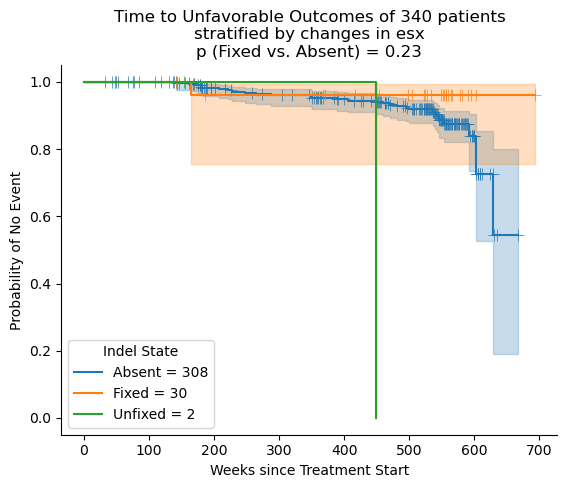

In [116]:
variant = 'esx'

pids_with_variant = sample_1_variants_grouped_pathways.loc[(sample_1_variants_grouped_pathways[variant] <= 0.75) & (sample_1_variants_grouped_pathways[variant] >= 0.05)].index.values

df_plot_outcome = plot_survival_curve_by_indel_baseline(df_imputed_patient_data_outcomes.query("pid not in @high_F2_pids.pid.values"),
                                                       df_tx_outcomes.query("pid in @df_trust_patients.pid"), # require this to exclude pid T0402 which has discordant WGS
                                                       'event',
                                                       'date',
                                                       variant,
                                                       sample_1_variants_grouped_pathways, 
                                                       exclude_fixed_absent=False,
                                                       change_thresh=0.05, 
                                                       freq_thresh=5,
                                                       logrank_test_compare_groups=['Fixed', 'Absent'], 
                                                       colors_dict = {'Fixed': '#ff7f0e', 'Absent': '#1f77b4', 'Unfixed': '#2ca02c', 'Loss': '#d62728'},
                                                       p=0,
                                                       q=0,
                                                       save=True
                                                      )

print("\n")

Rv0759c_c.-97_-96delGG: χ^2 = 9.542945791834331, p = 0.008467898636888313


PE_PGRS60: χ^2 = 4.007818429216499, p = 0.04528971639536179




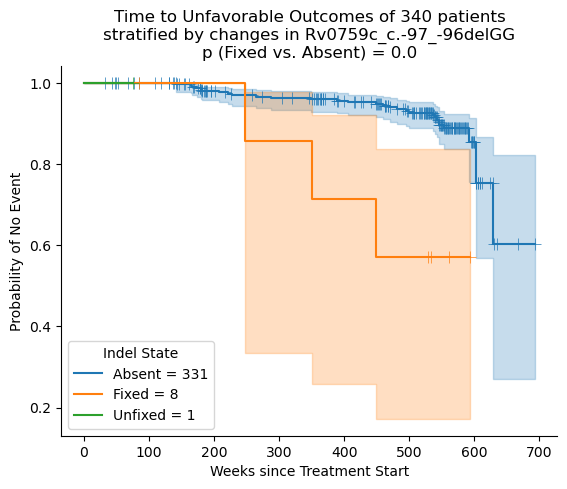

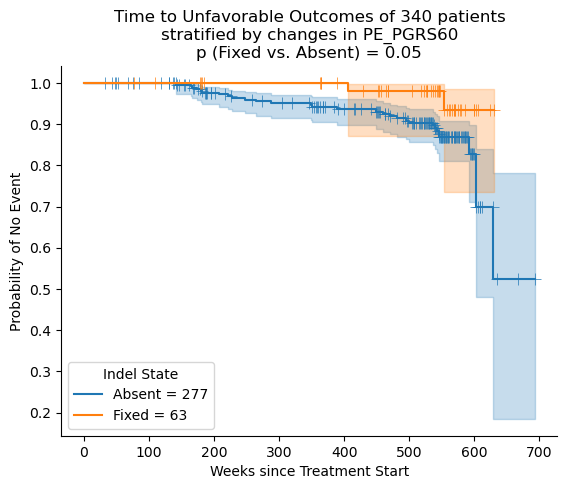

In [87]:
for i, row in df_results_all_indels_outcomes.query("pval <= 0.05 & covariate.str.contains('Indel')")[['covariate', 'Indel', 'OR_lower', 'OR', 'OR_upper']].iterrows():
    
    variant = row['Indel']
    
    pids_with_variant = sample_1_variants.loc[(sample_1_variants[variant] <= 0.75) & (sample_1_variants[variant] >= 0.05)].index.values
        
    df_plot_outcome = plot_survival_curve_by_indel_baseline(df_imputed_patient_data_outcomes.query("pid not in @high_F2_pids.pid.values"),
                                                           df_tx_outcomes.query("pid in @df_trust_patients.pid"), # require this to exclude pid T0402 which has discordant WGS
                                                           'event',
                                                           'date',
                                                           variant,
                                                           sample_1_variants, 
                                                           exclude_fixed_absent=False,
                                                           change_thresh=0.05, 
                                                           freq_thresh=5,
                                                           logrank_test_compare_groups=['Fixed', 'Absent'], 
                                                           colors_dict = {'Fixed': '#ff7f0e', 'Absent': '#1f77b4', 'Unfixed': '#2ca02c', 'Loss': '#d62728'},
                                                           p=0,
                                                           q=0,
                                                           save=True
                                                          )

    print("\n")

In [88]:
variant = 'PE_PGRS60'

label_dict = {'RIF_AUC': 'Rifampicin PK AUC',
              'INH_AUC': 'Isoniazid PK AUC',
              'EMB_AUC': 'Ethambutol PK AUC',
              'PZA_AUC': 'Pyrazinamide PK AUC',
              'screen_sex': 'Sex',
              'screen_years': 'Age',
              'bl_bmi': 'Body Mass Index',
              'smoked_substance_use': 'Smoked Substance Use',
              'HIV_High_CD4': 'HIV, CD4 ≥ 200 cells/$\mathregular{mm^3}$',
              'HIV_Low_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$',
              'INH_midpoing': 'Measured INH MIC',
              'bl_prevtb': 'Previous TB Disease',
              'smear_pos_no_contam_sputum_specimen_1': 'Smear Positivity',
              'diabetes': 'Diabetes',
              'Indel_Change': f'{variant} Gain',
              'Indel_Sample1': f'Frameshift in {variant}',
              'Indel_Sample1_x_Change': f'{variant} at Baseline x Gain',
              'Lineage_3': 'Lineage 3',
              'Lineage_4': 'Lineage 4',
              'total_adherence': 'Adherence Rate',
              'F2': 'F2 Strain Mixing Metric',
              'inh_resistant': 'INH Resistance',
              'high_lung_involvement': '>20% Lung Affected',
              'cxr_cavity_chest_radiograph_1': 'Cavitation',
              'fstrom1_baseline': 'Smoking',
              'Lineage_1': 'Lineage 1',
              'Lineage_3': 'Lineage 3',
              'Lineage_4': 'Lineage 4'
             }

forest_plot(df_results_all_indels_outcomes.query("Indel==@variant"), label_dict, val_col='OR', alpha=0.05, log=True, saveName=f"./results/figures/outcomes/{variant}_forest_plot.svg")

In [90]:
variant = 'Rv0759c_c.-97_-96delGG'

label_dict = {'RIF_AUC': 'Rifampicin PK AUC',
              'INH_AUC': 'Isoniazid PK AUC',
              'EMB_AUC': 'Ethambutol PK AUC',
              'PZA_AUC': 'Pyrazinamide PK AUC',
              'screen_sex': 'Sex',
              'screen_years': 'Age',
              'bl_bmi': 'Body Mass Index',
              'smoked_substance_use': 'Smoked Substance Use',
              'HIV_High_CD4': 'HIV, CD4 ≥ 200 cells/$\mathregular{mm^3}$',
              'HIV_Low_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$',
              'INH_midpoing': 'Measured INH MIC',
              'bl_prevtb': 'Previous TB Disease',
              'smear_pos_no_contam_sputum_specimen_1': 'Smear Positivity',
              'diabetes': 'Diabetes',
              'Indel_Change': f'{variant} Gain',
              'Indel_Sample1': f'{variant}',
              'Indel_Sample1_x_Change': f'{variant} at Baseline x Gain',
              'Lineage_3': 'Lineage 3',
              'Lineage_4': 'Lineage 4',
              'total_adherence': 'Adherence Rate',
              'F2': 'F2 Strain Mixing Metric',
              'inh_resistant': 'INH Resistance',
              'high_lung_involvement': '>20% Lung Affected',
              'cxr_cavity_chest_radiograph_1': 'Cavitation',
              'fstrom1_baseline': 'Smoking',
              'Lineage_1': 'Lineage 1',
              'Lineage_3': 'Lineage 3',
              'Lineage_4': 'Lineage 4'
             }

forest_plot(df_results_all_indels_outcomes.query("Indel==@variant"), label_dict, val_col='OR', alpha=0.05, log=True, saveName=f"./results/figures/outcomes/{variant}_forest_plot.svg")



In [99]:
pids_with_variant = list(set(sample_1_variants.loc[sample_1_variants[variant] > 0].index.values).intersection(df_tx_outcomes.pid))

df_trust_patients.query("pid in @pids_with_variant")[['pid', 'Lineage', 'inh_resistant']]

,pid,Lineage,inh_resistant
45,T0049,4.0,0.0
71,T0077,4,0.0
91,T0106,4,0.0
94,T0110,4,0.0
109,T0125,4,0.0
130,T0149,4,0.0
182,T0205,4,0.0
193,T0217,2.0,0.0
229,T0257,4,0.0


In [104]:
non_coding_regions = h37Rv_regions.query("Feature != 'CDS'").Name.values

In [108]:
df_variants.query("GENE in @non_coding_regions").drop_duplicates(subset=['variant', 'pid']).variant.value_counts()

variant
F6_n.30dupC       317
mcr11_n.95delC    220
Name: count, dtype: int64

In [138]:
4094527-4093940

587

In [91]:
PE_PGRS60_start = h37Rv_genes.query("Symbol == 'PE_PGRS60'").Start.values[0]
PE_PGRS60_end = h37Rv_genes.query("Symbol == 'PE_PGRS60'").End.values[0]

In [123]:
PE_PGRS60_AA = h37Rv_seq.seq[PE_PGRS60_start-1:PE_PGRS60_end].translate()

# delete G at 4093880
del_pos = 4093880

# skip the deletion position
PE_PGRS60_frameshifted_NT = h37Rv_seq.seq[PE_PGRS60_start-1:del_pos-1] + h37Rv_seq.seq[del_pos:]
PE_PGRS60_frameshifted_AA = PE_PGRS60_frameshifted_NT.translate()

# PE_PGRS60 is 104 AA long, and PE_PGRS61 is 195 AA long. The frameshifted protein would terminate at 221 AA long, which is 74% of the length
stop_codon_pos = PE_PGRS60_frameshifted_AA.find("*")
stop_codon_pos

221

In [136]:
PE_PGRS60_frameshifted_AA[:stop_codon_pos]

Seq('MSYVIAAPEALVAAATDLATLGSTIGAANAAAAGSTTALLTAGADEVSAAIAAY...VGR')

In [133]:
# in Mtb 18B assembly, they are one ORF, which is 306 AA long
Mtb_18B_PE_PGRS6061_NT = Seq.Seq("gtgtccgatgtcatatgtgatcgcggcgccggaggcgctggtggcggcggccacggatttggctactctcggctcgacgatcggcgccgccaacgcggccgctgcgggctcgacaacggcgttgctgaccgccggcgccgacgaagtgtcggcggcgatagcggcctattcggaatgcacggccagacctatcaggcactcagtgcgcgggcggcggcgttccatgagcggttcgtgcaggccttggccacaggtgggggcgcctatgcggccgccgaggccgccagcgtctcgccgctgcagagcgcgctcgatttgctgaatgcgcccactcaggcgctgttggggcgtccgttggtgggcaatggcgccaatggggccccggggactggggcaaacggcggcgatggcgggattttgttcgggtccgggggggccggcgggtccggagcggccggcatggcgggtggcaacggcggggccgccgggctgttcggcaacggcggagccggcggagccggcggcagcgcgacggccggtgcggccggggcgggcgggaacggcggggccggcgggctgctgttcggtaccgccggggccggcggcaacggcgggttaagcctcggtttgggcgtcgccggcggcgccggcggcgccggcgggtcgggcggtagtgacaccgccggacacggggggaccggtggtgccggcggcctgctattcggcgccggcggcgccggcggcgccggcgaggacggcacaacgcccggtggcaacggtggggcgggcggtgtcgccgggctgttcggcgacggcggcaacggtggtaacgccggagttggcacgcccgcgggcaacgtcggcgccggcggcaccggcggcctgctgctcggccaggacggcatgaccgggttgacgtag")

Mtb_18B_PE_PGRS6061_AA = Mtb_18B_PE_PGRS6061_NT.translate()

In [134]:
Mtb_18B_PE_PGRS6061_AA

Seq('VSDVICDRGAGGAGGGGHGFGYSRLDDRRRQRGRCGLDNGVADRRRRRSVGGDS...LT*')

In [137]:
len(Mtb_18B_PE_PGRS6061_AA)

307

In [109]:
h37Rv_seq.seq[PE_PGRS60_start-1:del_pos-1] + Seq.Seq('A')

Seq('ATGTCATATGTGATCGCGGCGCCGGAGGCGCTGGTGGCGGCGGCCACGGATTTG...GTA')

In [104]:
h37Rv_seq.seq[PE_PGRS60_start-1:4093879]

Seq('ATGTCATATGTGATCGCGGCGCCGGAGGCGCTGGTGGCGGCGGCCACGGATTTG...GGT')

In [ ]:
h37Rv_seq.seq[PE_PGRS60_start-1:4093879]

In [100]:
h37Rv_seq[4093880-1]

'G'

In [97]:
PE_PGRS60_AA

Seq('MSYVIAAPEALVAAATDLATLGSTIGAANAAAAGSTTALLTAGADEVSAAIAAY...IC*')

In [99]:
df_variants.query("GENE=='PE_PGRS60'")

,pid,SampleID,POS,REF,ALT,QUAL,DP,DPB,RO,AO,...,variant,SRP_prob,SAP_prob,HT,Diff_NT,Unique_Change_NT,Phase_Variant,SNP,Sampling_Week,Paired_Sample_Num
9,T0001,MFS-331,4093879,TG,T,7245.65,240,213.333,0,240.0,...,PE_PGRS60_p.Ala85fs,NaN,0.059222,1,G,1.0,1,0,1.0,1
22,T0002,MFS-509,4093879,TG,T,7021.44,232,206.333,0,232.0,...,PE_PGRS60_p.Ala85fs,NaN,0.005229,1,G,1.0,1,0,1.0,1
34,T0002,MFS-510,4093879,TG,T,6089.29,202,179.556,0,202.0,...,PE_PGRS60_p.Ala85fs,NaN,0.150896,1,G,1.0,1,0,5.0,2
638,T0013,MFS-6,4093879,TG,T,8012.36,265,235.667,0,265.0,...,PE_PGRS60_p.Ala85fs,NaN,0.005389,1,G,1.0,1,0,9.0,2
674,T0016,MFS-519,4093879,TG,T,6214.21,206,183.111,0,206.0,...,PE_PGRS60_p.Ala85fs,NaN,0.001863,1,G,1.0,1,0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19898,T0437,MFS-702,4093879,TG,T,6608.17,219,194.667,0,219.0,...,PE_PGRS60_p.Ala85fs,NaN,0.073296,1,G,1.0,1,0,1.0,1
19912,T0437,MFS-819,4093879,TG,T,6288.74,180,160.111,0,178.0,...,PE_PGRS60_p.Ala85fs,NaN,0.377552,1,G,1.0,1,0,5.0,2
20225,T0444,MFS-707,4093879,TG,T,2636.85,287,266.333,101,186.0,...,PE_PGRS60_p.Ala85fs,0.334828,0.022356,1,G,1.0,1,0,1.0,1
20612,T0452,MFS-714,4093879,TG,T,6932.99,231,205.333,0,230.0,...,PE_PGRS60_p.Ala85fs,NaN,0.000883,1,G,1.0,1,0,1.0,1


In [112]:
df_variants.query("variant==@variant").Lineage.value_counts()

Lineage
4.0    18
4       2
2.0     1
2.0     1
Name: count, dtype: int64

In [113]:
df_variants.query("variant==@variant").Coll2014.value_counts()

Coll2014
4.1.1.1    14
4.1.2.1     2
4.1.1.3     2
4.1         2
2.2.1.1     2
Name: count, dtype: int64

In [117]:
df_variants.query("variant==@variant & AF <= 0.75")[['pid', 'SampleID', 'F2', 'POS', 'REF', 'ALT', 'DP', 'AO', 'AF']]

,pid,SampleID,F2,POS,REF,ALT,DP,AO,AF
21578,T0217,MFS-758,0.011056,854252,GCC,G,290,173.0,0.596552


In [120]:
df_variants.query("variant==@variant & pid=='T0217'")[['pid', 'SampleID', 'F2', 'POS', 'REF', 'ALT', 'DP', 'AO', 'AF', 'Sampling_Week', 'Paired_Sample_Num']].sort_values('Paired_Sample_Num')

,pid,SampleID,F2,POS,REF,ALT,DP,AO,AF,Sampling_Week,Paired_Sample_Num
21578,T0217,MFS-758,0.011056,854252,GCC,G,290,173.0,0.596552,1,1
9802,T0217,MFS-759,0.011409,854252,GCC,G,231,174.0,0.753247,5,2


In [121]:
df_tx_outcomes.query("pid=='T0217'")

,pid,date,event_type,to_studyto_treatment_outcome,esp_reason_end_of_study_parti,esp_reasonoth_end_of_study_parti,esp_date_end_of_study_parti,waiver_reason_end_of_study_parti,esp_cod_end_of_study_parti,waiver_deathcause_end_of_study_parti,TB_death,event,reenroll,unique_patient,weeks,months,imp_num
180,T0217,76.0,cure,3.0,7.0,NaN,217.0,NaN,NaN,NaN,NaN,0,0,227,10.857143,2.533333,0


In [129]:
df_trust_patients.columns[df_trust_patients.columns.str.contains('comment', case=False)]

Index(['Comment', 'comment', 'inh_dst_comment_sputum_specimen_13',
       'rif_dst_comment_sputum_specimen_13', 'to_comments_treatment_outcome',
       'dna_comments_dna_extract_1', 'dna_comments_dna_extract_2'],
      dtype='object')

In [132]:
df_trust_patients.query("pid=='T0217'")[['to_comments_treatment_outcome', 'comment']].to_comments_treatment_outcome.values

array(['Verbal confirmation from Sr at TB Clinic that patient is regarded as "Treatment Defaulted" as she was loss to follow-up (no treatment received for more than two months). Did not finish TB Treatment.',
       'Verbal confirmation from Sr at TB Clinic that patient is regarded as "Treatment Defaulted" as she was loss to follow-up (no treatment received for more than two months). Did not finish TB Treatment.'],
      dtype=object)

In [68]:
sample_1_variants.loc[(sample_1_variants['PE_PGRS60'] <= 0.75) & (sample_1_variants['PE_PGRS60'] > 0)]['PE_PGRS60']

T0444    0.648084
T0087    0.404167
T0072    0.400901
T0066    0.059524
T0311    0.323404
T0305    0.525773
T0267    0.213953
Name: PE_PGRS60, dtype: float64

In [53]:
df_variants.query("GENE=='PE_PGRS60'")[['POS', 'REF', 'ALT', 'variant']].drop_duplicates()

,POS,REF,ALT,variant
9,4093879,TG,T,PE_PGRS60_p.Ala85fs


In [57]:
df_variants.query("GENE=='PE_PGRS60'").sort_values("SampleID")[['pid', 'SampleID', 'SAF', 'SAR', 'SAP_prob']]

,pid,SampleID,SAF,SAR,SAP_prob
892,T0021,MFS-10,70.0,142.0,0.000002
8288,T0186,MFS-104,83.0,94.0,0.355243
8301,T0186,MFS-105,61.0,84.0,0.080679
8400,T0188,MFS-106,72.0,97.0,0.078688
8687,T0196,MFS-111,97.0,99.0,0.494923
...,...,...,...,...,...
20126,T0452,MFS-831,93.0,102.0,0.406228
879,T0021,MFS-9,63.0,97.0,0.013492
7715,T0171,MFS-90,98.0,143.0,0.007488
7768,T0173,MFS-91,74.0,116.0,0.004819


In [146]:
for variant in df_results_all_indels_outcomes.query("pval <= 0.05 & covariate.str.contains('Indel')").Indel.values:
    
    pids_with_variant = sample_1_variants.loc[sample_1_variants[variant]==1].index.values
    
    print(variant, pids_with_variant)

fhaB_c.-36delG ['T0187' 'T0233' 'T0272' 'T0380' 'T0384']
Rv0759c_c.-97_-96delGG ['T0049' 'T0077' 'T0091' 'T0106' 'T0125' 'T0149' 'T0205' 'T0257' 'T0330']
Rv3128c_c.-139_-140insCC,Rv3129_c.-340_-339insCC ['T0187' 'T0233' 'T0272' 'T0380' 'T0384']
Rv0192 ['T0187' 'T0233' 'T0272' 'T0380' 'T0384']
Rv1215c ['T0049' 'T0091' 'T0149' 'T0205' 'T0257' 'T0330']
PE_PGRS31 ['T0049' 'T0091' 'T0149' 'T0205' 'T0257' 'T0330']
mce3B ['T0187' 'T0233' 'T0272' 'T0380' 'T0384']
ahpD ['T0049' 'T0091' 'T0149' 'T0205' 'T0257' 'T0330']


In [ ]:
# ['T0049' 'T0091' 'T0149' 'T0205' 'T0257' 'T0330'] have the variants in
# Rv0759c_c.-97_-96delGG, Rv1215c, PE_PGRS31, and ahpD

In [199]:
pids_with_same_variants = ['T0049', 'T0091', 'T0149', 'T0205', 'T0257', 'T0330']
sample_1_variants.loc[pids_with_same_variants, ['Rv0759c_c.-97_-96delGG', 'Rv1215c', 'PE_PGRS31', 'ahpD']]

,Rv0759c_c.-97_-96delGG,Rv1215c,PE_PGRS31,ahpD
T0049,1.0,1.0,1.0,1.0
T0091,1.0,1.0,1.0,1.0
T0149,1.0,1.0,1.0,1.0
T0205,1.0,1.0,1.0,1.0
T0257,1.0,1.0,1.0,1.0
T0330,1.0,1.0,1.0,1.0


In [202]:
df_variants.query("pid in @pids_with_same_variants").drop_duplicates(subset='pid').Coll2014.value_counts()

Coll2014
4.1.1.1    6
Name: count, dtype: int64

In [208]:
pids_for_analysis.query("pid in @pids_with_same_variants").columns

Index(['pid', 'Original_ID', 'SampleID', 'SampleLib', 'Pacbio', 'Comment',
       'quality', 'Cov_Any_Mean', 'Cov_Unam_Perc', 'Perc_Reads_Mapped',
       ...
       'last_dots_date', 'F2', 'Coll2014', 'Freschi2020', 'Lineage',
       'Sampling_Week', 'Paired_Sample_Num', 'Kraken_Unclassified_Percent',
       'high_F2', 'pid_high_F2'],
      dtype='object', length=7106)

In [209]:
df_variants

,pid,SampleID,Sampling_Week,Paired_Sample_Num,POS,REF,ALT,QUAL,DP,DPB,...,SAP_prob,F2,Lineage,Coll2014,HT,variant,Diff_NT,Unique_Change_NT,Phase_Variant,SNP


In [204]:
df_variants.query("pid in @pids_with_same_variants & GENE=='Rv1215c'")

,pid,SampleID,Sampling_Week,Paired_Sample_Num,POS,REF,ALT,QUAL,DP,DPB,...,SAP_prob,F2,Lineage,Coll2014,HT,variant,Diff_NT,Unique_Change_NT,Phase_Variant,SNP
1980,T0049,MFS-28,1,1,1358906,AC,A,4917.45,163,142.750,...,0.017710,0.008670,4,4.1.1.1,1,Rv1215c_p.Val180fs,C,1.0,1,0
1999,T0049,MFS-29,8,2,1358906,AC,A,5206.87,173,152.000,...,0.001436,0.008782,4,4.1.1.1,1,Rv1215c_p.Val180fs,C,1.0,1,0
3838,T0091,MFS-564,1,1,1358906,AC,A,5851.90,193,169.625,...,0.099031,0.008389,4,4.1.1.1,1,Rv1215c_p.Val180fs,C,1.0,1,0
3857,T0091,MFS-736,5,2,1358906,AC,A,13423.00,378,330.750,...,0.000507,0.007203,4,4.1.1.1,1,Rv1215c_p.Val180fs,C,1.0,1,0
5433,T0149,MFS-604,1,1,1358906,AC,A,6332.03,210,184.125,...,0.087408,0.004925,4,4.1.1.1,1,Rv1215c_p.Val180fs,C,1.0,1,0
5452,T0149,MFS-605,5,2,1358906,AC,A,7032.67,234,204.750,...,0.116479,0.012019,4,4.1.1.1,1,Rv1215c_p.Val180fs,C,1.0,1,0
7523,T0205,MFS-633,1,1,1358906,AC,A,6545.98,216,189.625,...,0.046723,0.006866,4,4.1.1.1,1,Rv1215c_p.Val180fs,C,1.0,1,0
7542,T0205,MFS-634,4,2,1358906,AC,A,6031.56,201,176.125,...,0.002521,0.005875,4,4.1.1.1,1,Rv1215c_p.Val180fs,C,1.0,1,0
9549,T0257,MFS-174,1,1,1358906,AC,A,6036.97,200,175.125,...,0.003953,0.008193,4,4.1.1.1,1,Rv1215c_p.Val180fs,C,1.0,1,0
9568,T0257,MFS-175,7,2,1358906,AC,A,7561.74,253,222.250,...,0.004186,0.008737,4,4.1.1.1,1,Rv1215c_p.Val180fs,C,1.0,1,0


In [184]:
# variant = 'mce3B'
variant = 'Rv0759c_c.-97_-96delGG'
pids_with_variant = sample_1_variants.loc[sample_1_variants[variant]==1].index.values

In [186]:
df_variants.query("pid in @pids_with_variant & variant==@variant")

,pid,SampleID,Sampling_Week,Paired_Sample_Num,POS,REF,ALT,QUAL,DP,DPB,...,SAP_prob,F2,Lineage,Coll2014,HT,variant,Diff_NT,Unique_Change_NT,Phase_Variant,SNP
1979,T0049,MFS-28,1,1,854252,GCC,G,6549.16,216,183.000,...,0.163079,0.008670,4,4.1.1.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0
1998,T0049,MFS-29,8,2,854252,GCC,G,6775.09,223,188.923,...,0.381194,0.008782,4,4.1.1.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0
3248,T0077,MFS-43,1,1,854252,GCC,G,8375.10,275,232.769,...,0.491884,0.021399,4,4.1.2.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0
3268,T0077,MFS-44,6,2,854252,GCC,G,5893.26,196,165.846,...,0.344976,0.021498,4,4.1.2.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0
3837,T0091,MFS-564,1,1,854252,GCC,G,8819.64,293,247.923,...,0.500000,0.008389,4,4.1.1.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0
3856,T0091,MFS-736,5,2,854252,GCC,G,17246.30,481,407.077,...,0.495344,0.007203,4,4.1.1.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0
4097,T0106,MFS-56,1,1,854252,GCC,G,7749.28,255,215.923,...,0.096119,0.018698,4,4.1.1.3,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0
4117,T0106,MFS-57,8,2,854252,GCC,G,9041.80,297,251.308,...,0.307377,0.017603,4,4.1.1.3,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0
4729,T0125,MFS-588,1,1,854252,GCC,G,9804.43,323,274.000,...,0.493082,0.023414,4,4.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0
4746,T0125,MFS-589,8,2,854252,GCC,G,7167.30,237,200.538,...,0.179322,0.020902,4,4.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0


In [187]:
df_tx_outcomes.query("pid in @pids_with_variant")

,pid,date,event_type,to_studyto_treatment_outcome,esp_reason_end_of_study_parti,esp_reasonoth_end_of_study_parti,esp_date_end_of_study_parti,waiver_reason_end_of_study_parti,esp_cod_end_of_study_parti,waiver_deathcause_end_of_study_parti,TB_death,event,reenroll,unique_patient,weeks,months,imp_num
39,T0049,449.0,relapse,2.0,5.0,NaN,449.0,NaN,NaN,NaN,NaN,1,0,21,64.142857,14.966667,0
63,T0077,534.0,cure,1.0,1.0,NaN,534.0,NaN,NaN,NaN,NaN,0,0,118,76.285714,17.800000,0
83,T0106,529.0,cure,1.0,1.0,NaN,529.0,NaN,NaN,NaN,NaN,0,0,140,75.571429,17.633333,0
99,T0125,593.0,cure,1.0,1.0,NaN,593.0,NaN,NaN,NaN,NaN,0,0,153,84.714286,19.766667,0
118,T0149,561.0,cure,1.0,1.0,NaN,561.0,NaN,NaN,NaN,NaN,0,0,172,80.142857,18.700000,0
170,T0205,84.0,cure,9.0,3.0,NaN,84.0,NaN,NaN,NaN,NaN,0,0,219,12.000000,2.800000,0
210,T0257,350.0,relapse,1.0,5.0,NaN,350.0,1.0,NaN,NaN,NaN,1,1,5,50.000000,11.666667,0


In [193]:
df_pred_combined.query("pid in @pids_with_variant")

,pid,RIF_pred_MIC,INH_pred_MIC,EMB_pred_MIC,PZA_pred_MIC
44,T0049,0.064936,0.049973,0.919206,24.936594
69,T0077,0.060977,0.050339,1.280068,24.756018
82,T0091,0.065054,3.285629,0.919206,24.936594
91,T0106,0.064164,0.051246,1.326902,24.936594
109,T0125,0.061919,0.050146,1.237477,25.042257
130,T0149,0.064936,0.049973,0.919206,24.936594
183,T0205,0.064936,0.049973,0.919206,24.936594
230,T0257,0.064936,0.049973,0.919206,24.936594
290,T0330,0.064936,0.049973,0.919206,24.936594


In [194]:
TRUST_phenos.query("pid in @pids_with_variant")

,pid,RIF_lower_bound,RIF_upper_bound,RIF_midpoint,INH_lower_bound,INH_upper_bound,INH_midpoint,EMB_lower_bound,EMB_upper_bound,EMB_midpoint,PZA_lower_bound,PZA_upper_bound,PZA_midpoint
241,T0091,0.030,0.060,0.0450,0.100,0.20,0.1500,0.6,1.25,0.925,NaN,NaN,NaN
2092,T0125,0.060,0.125,0.0925,0.025,0.05,0.0375,0.6,1.25,0.925,NaN,NaN,NaN
2175,T0149,0.125,0.250,0.1875,0.025,0.05,0.0375,0.6,1.25,0.925,25.0,50.0,37.5
2410,T0205,0.060,0.125,0.0925,0.025,0.05,0.0375,0.0,0.60,0.300,NaN,NaN,NaN
2539,T0330,0.060,0.125,0.0925,0.025,0.05,0.0375,0.6,1.25,0.925,0.0,25.0,12.5
3777,T0077,0.060,0.125,0.0925,0.025,0.05,0.0375,0.0,0.60,0.300,0.0,25.0,12.5
3860,T0049,0.125,0.250,0.1875,0.025,0.05,0.0375,0.6,1.25,0.925,NaN,NaN,NaN
4216,T0106,0.060,0.125,0.0925,0.025,0.05,0.0375,0.6,1.25,0.925,0.0,25.0,12.5
4457,T0257,0.060,0.125,0.0925,0.025,0.05,0.0375,0.6,1.25,0.925,25.0,50.0,37.5


In [155]:
df_variants.query("pid in ['T0049', 'T0091', 'T0149', 'T0205', 'T0257', 'T0330']").Coll2014.unique()

array(['4.1.1.1'], dtype=object)

In [152]:
df_variants.query("pid=='T0049' & GENE.str.contains('|'.join(['Rv0759c', 'Rv1215c', 'PE_PGRS31', 'ahpD']))")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'variant', 'Lineage']]

,pid,SampleID,POS,REF,ALT,variant,Lineage
1979,T0049,MFS-28,854252,GCC,G,Rv0759c_c.-97_-96delGG,4
1980,T0049,MFS-28,1358906,AC,A,Rv1215c_p.Val180fs,4
1984,T0049,MFS-28,2001878,CG,C,PE_PGRS31_p.Gly424fs,4
1988,T0049,MFS-28,2726815,GA,G,ahpD_p.Lys5fs,4
1998,T0049,MFS-29,854252,GCC,G,Rv0759c_c.-97_-96delGG,4
1999,T0049,MFS-29,1358906,AC,A,Rv1215c_p.Val180fs,4
2003,T0049,MFS-29,2001878,CG,C,PE_PGRS31_p.Gly424fs,4
2007,T0049,MFS-29,2726815,GA,G,ahpD_p.Lys5fs,4


In [31]:
df_variants.query("variant=='Rv0759c_c.-97_-96delGG' & F2 <= 0.03")[['REF', 'ALT', 'variant', 'AF', 'variant']]#.variant.value_counts()

,REF,ALT,variant,AF,variant
1979,GCC,G,Rv0759c_c.-97_-96delGG,1.000000,Rv0759c_c.-97_-96delGG
1998,GCC,G,Rv0759c_c.-97_-96delGG,1.000000,Rv0759c_c.-97_-96delGG
3248,GCC,G,Rv0759c_c.-97_-96delGG,1.000000,Rv0759c_c.-97_-96delGG
3268,GCC,G,Rv0759c_c.-97_-96delGG,0.989796,Rv0759c_c.-97_-96delGG
3837,GCC,G,Rv0759c_c.-97_-96delGG,0.989761,Rv0759c_c.-97_-96delGG
3856,GCC,G,Rv0759c_c.-97_-96delGG,1.000000,Rv0759c_c.-97_-96delGG
4097,GCC,G,Rv0759c_c.-97_-96delGG,1.000000,Rv0759c_c.-97_-96delGG
4117,GCC,G,Rv0759c_c.-97_-96delGG,1.000000,Rv0759c_c.-97_-96delGG
4729,GCC,G,Rv0759c_c.-97_-96delGG,1.000000,Rv0759c_c.-97_-96delGG
4746,GCC,G,Rv0759c_c.-97_-96delGG,0.995781,Rv0759c_c.-97_-96delGG


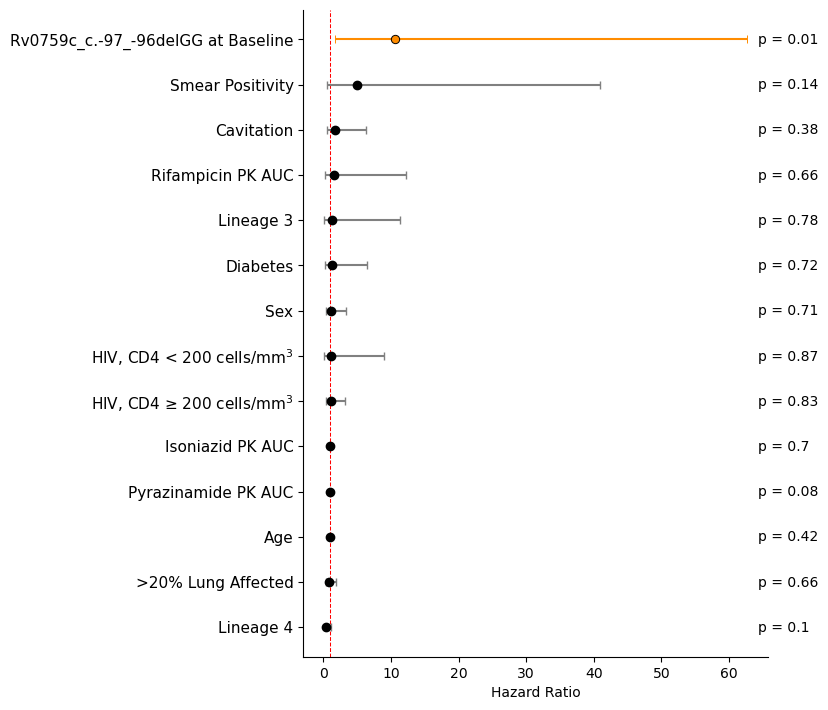

In [191]:
variant = 'Rv0759c_c.-97_-96delGG'
# variant = 'ahpD'

label_dict = {'RIF_AUC': 'Rifampicin PK AUC',
              'INH_AUC': 'Isoniazid PK AUC',
              'EMB_AUC': 'Ethambutol PK AUC',
              'PZA_AUC': 'Pyrazinamide PK AUC',
              'screen_sex': 'Sex',
              'screen_years': 'Age',
              'bl_bmi': 'Body Mass Index',
              'smoked_substance_use': 'Smoked Substance Use',
              'HIV_High_CD4': 'HIV, CD4 ≥ 200 cells/$\mathregular{mm^3}$',
              'HIV_Low_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$',
              'INH_midpoing': 'Measured INH MIC',
              'bl_prevtb': 'Previous TB Disease',
              'smear_pos_no_contam_sputum_specimen_1': 'Smear Positivity',
              'diabetes': 'Diabetes',
              'Indel_Change': f'{variant} Gain',
              'Indel_Sample1': f'{variant} at Baseline',
              'Indel_Sample1_x_Change': f'{variant} at Baseline x Gain',
              'Lineage_3': 'Lineage 3',
              'Lineage_4': 'Lineage 4',
              'total_adherence': 'Adherence Rate',
              'F2': 'F2 Strain Mixing Metric',
              'inh_resistant': 'INH Resistance',
              'high_lung_involvement': '>20% Lung Affected',
              'cxr_cavity_chest_radiograph_1': 'Cavitation',
              'fstrom1_baseline': 'Smoking'
             }

forest_plot(df_results_all_indels_outcomes.query("Indel==@variant & covariate != 'inh_resistant' & covariate != 'Indel_Change'"), label_dict, val_col='OR', alpha=0.05)#, saveName=f"./results/figures/outcomes/{variant}.svg")

In [32]:
variant = 'Rv0759c_c.-97_-96delGG'
pids_with_variant = sample_1_variants.loc[sample_1_variants[variant] > 0].index.values

In [33]:
df_tx_outcomes.query("pid in @pids_with_variant")

,pid,date,event_type,to_studyto_treatment_outcome,esp_reason_end_of_study_parti,esp_reasonoth_end_of_study_parti,esp_date_end_of_study_parti,waiver_reason_end_of_study_parti,esp_cod_end_of_study_parti,waiver_deathcause_end_of_study_parti,TB_death,event,reenroll,unique_patient,weeks,months
39,T0049,449.0,relapse,2.0,5.0,NaN,449.0,NaN,NaN,NaN,NaN,1,0,21,64.142857,14.966667
63,T0077,534.0,cure,1.0,1.0,NaN,534.0,NaN,NaN,NaN,NaN,0,0,118,76.285714,17.800000
83,T0106,529.0,cure,1.0,1.0,NaN,529.0,NaN,NaN,NaN,NaN,0,0,140,75.571429,17.633333
99,T0125,593.0,cure,1.0,1.0,NaN,593.0,NaN,NaN,NaN,NaN,0,0,153,84.714286,19.766667
118,T0149,561.0,cure,1.0,1.0,NaN,561.0,NaN,NaN,NaN,NaN,0,0,172,80.142857,18.700000
170,T0205,84.0,cure,9.0,3.0,NaN,84.0,NaN,NaN,NaN,NaN,0,0,219,12.000000,2.800000
180,T0217,76.0,cure,3.0,7.0,NaN,217.0,NaN,NaN,NaN,NaN,0,0,227,10.857143,2.533333
210,T0257,350.0,relapse,1.0,5.0,NaN,350.0,1.0,NaN,NaN,NaN,1,1,5,50.000000,11.666667


In [38]:
df_tx_outcomes.event_type.value_counts()

event_type
cure          230
relapse        18
death          11
tx_failure      4
Name: count, dtype: int64

In [34]:
df_imputed_patient_data_outcomes[['pid', 'inh_resistant']].query("pid in @pids_with_variant").drop_duplicates()

,pid,inh_resistant
39,T0049,0.0
63,T0077,0.0
83,T0106,0.0
100,T0125,0.0
119,T0149,0.0
171,T0205,0.0
181,T0217,0.0
212,T0257,0.0
270,T0330,0.0


In [35]:
df_pred_combined.query("pid in @pids_with_variant")

NameError: name 'df_pred_combined' is not defined

In [36]:
sample_1_variants.loc[sample_1_variants[variant] > 0][variant]

T0049    1.000000
T0077    1.000000
T0091    0.989761
T0106    1.000000
T0125    1.000000
T0149    0.992424
T0205    0.996296
T0217    0.596552
T0257    1.000000
T0330    0.995516
Name: Rv0759c_c.-97_-96delGG, dtype: float64

In [37]:
sample_2_variants.loc[sample_2_variants[variant] > 0][variant]

T0049    1.000000
T0077    0.989796
T0091    1.000000
T0106    1.000000
T0125    0.995781
T0149    0.996835
T0205    0.984375
T0217    0.753247
T0257    0.993769
T0330    1.000000
Name: Rv0759c_c.-97_-96delGG, dtype: float64

In [283]:
variant_differences[variant].value_counts()

Rv0759c_c.-97_-96delGG
 0.000000    267
-0.009950      1
 0.009868      1
-0.004049      1
-0.007475      1
 0.164983      1
-0.005848      1
 0.004255      1
Name: count, dtype: int64

In [144]:
search_pids = sample_1_variants.loc[sample_1_variants[variant] > 0.05].index.values
len(search_pids)

9

In [145]:
df_tx_outcomes.query("pid in @search_pids")[['pid', 'event_type', 'date', 'event']]

,pid,event_type,date,event
39,T0049,relapse,449.0,1
63,T0077,cure,534.0,0
83,T0106,cure,529.0,0
99,T0125,cure,593.0,0
170,T0205,cure,84.0,0
180,T0217,cure,76.0,0
210,T0257,relapse,350.0,1
